# Create and analyze trends across the summer stats from the Fourier Fits and compare with the Polynomial Fits

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

## Load LSM for filtering

In [2]:
file_path = '../../../Data/ERA5-global/ERA5-2023-09-01-CoordFixed-LSM.nc'
ds_lsm = xr.open_dataset(file_path)
ds_lsm

<xarray.Dataset> Size: 8MB
Dimensions:  (lat: 721, lon: 1440)
Coordinates:
  * lat      (lat) float32 3kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon      (lon) float32 6kB -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
Data variables:
    lsm      (lat, lon) float64 8MB ...

## load data from a couple of years to test Fourier results

In [4]:
%%time

# takes about 55 sec

# start with one year and lsm and add a coordinate for the year
year = 1961
input_path = '../../../Data/ERA5-global/Analysis/New-Fourier/'+str(year)+'_summer_stats.nc'
ds = xr.open_dataset(input_path)
ds = ds.merge(ds_lsm)
ds = ds.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))

# loop thru remaining years and also add time coord
input_years = np.arange(1962,1963,1)

for year in input_years:
    input_path = '../../../Data/ERA5-global/Analysis/New-Fourier/'+str(year)+'_summer_stats.nc'
    ds_i = xr.open_dataset(input_path)
    ds_i = ds_i.merge(ds_lsm)
    ds_i = ds_i.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))
    ds = ds.merge(ds_i)

ds

CPU times: user 87.1 ms, sys: 75.4 ms, total: 163 ms
Wall time: 166 ms


<xarray.Dataset> Size: 166MB
Dimensions:       (lat: 721, lon: 1440, time: 2)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time          (time) datetime64[ns] 16B 1961-01-01 1962-01-01
Data variables:
    SummerStart   (time, lat, lon) float64 17MB 136.0 136.0 ... 163.0 163.0
    SummerEnd     (time, lat, lon) float64 17MB 222.0 222.0 ... 233.0 233.0
    SummerTmax    (time, lat, lon) float64 17MB 179.0 179.0 ... 192.0 192.0
    SummerHeat    (time, lat, lon) float64 17MB 389.4 389.4 ... 220.3 220.3
    SummerLength  (time, lat, lon) float64 17MB 87.0 87.0 87.0 ... 71.0 71.0
    SummerRMSE    (time, lat, lon) float64 17MB 4.261 4.261 ... 3.744 3.744
    SummerR2      (time, lat, lon) float64 17MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    SummerMeanT   (time, lat, lon) float64 17MB 240.7 240.7 ... 273.9 273.9
    SummerMeanHS  (time, lat, lon) float64 17MB 4.993 4.993 ... 3.103 3.103
    lsm           (time, lat, lon) float64 17MB 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0

### Map of summer length

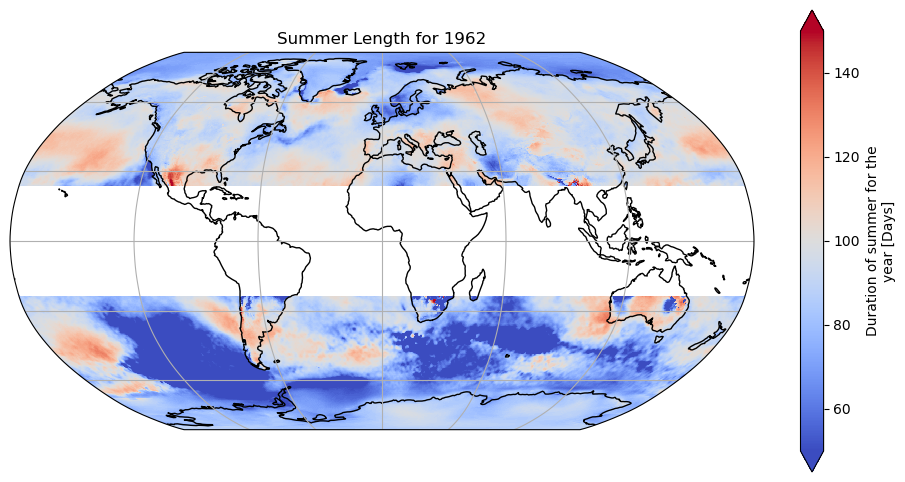

In [8]:
input_year=1962

# Global summer length for the year
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines()

ds.SummerLength.sel(time=str(input_year)).where((ds.lat <= -23.5) | (ds.lat >= 23.5)).plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=50,
    vmax=150, # define range to include an entire year
    cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)

plt.title("Summer Length for "+str(input_year))#+" using 1961-1990 baseline")
#plt.savefig("./Plots/"+str(input_year)+"_SummerMeanHS_global.png")
plt.show()

### should compare results from polynomial fit and fourier for metrics and also RMSE values

# **********

## load data from analysis period 1990-2023 

In [3]:
%%time

# takes about 55 sec

# start with one year and lsm and add a coordinate for the year
year = 1990
input_path = '../../../Data/ERA5-global/Analysis/New/'+str(year)+'_summer_stats.nc'
ds = xr.open_dataset(input_path)
ds = ds.merge(ds_lsm)
ds = ds.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))

# loop thru remaining years and also add time coord
input_years = np.arange(1991,2024,1)

for year in input_years:
    input_path = '../../../Data/ERA5-global/Analysis/New/'+str(year)+'_summer_stats.nc'
    ds_i = xr.open_dataset(input_path)
    ds_i = ds_i.merge(ds_lsm)
    ds_i = ds_i.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))
    ds = ds.merge(ds_i)

ds

CPU times: user 24.9 s, sys: 35.7 s, total: 1min
Wall time: 1min 12s


<xarray.Dataset> Size: 3GB
Dimensions:       (lat: 721, lon: 1440, time: 34)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time          (time) datetime64[ns] 272B 1990-01-01 ... 2023-01-01
Data variables:
    SummerStart   (time, lat, lon) float64 282MB 146.0 146.0 ... 216.0 216.0
    SummerEnd     (time, lat, lon) float64 282MB 220.0 220.0 ... 247.0 247.0
    SummerTmax    (time, lat, lon) float64 282MB 174.0 174.0 ... 231.0 231.0
    SummerHeat    (time, lat, lon) float64 282MB 663.9 663.9 ... 69.28 69.28
    SummerLength  (time, lat, lon) float64 282MB 75.0 75.0 75.0 ... 32.0 32.0
    SummerRMSE    (time, lat, lon) float64 282MB 7.937 7.937 ... 5.387 5.387
    SummerR2      (time, lat, lon) float64 282MB 0.5064 0.5064 ... 0.735 0.735
    SummerMeanT   (time, lat, lon) float64 282MB 245.3 245.3 ... 272.9 272.9
    SummerMeanHS  (time, lat, lon) float64 282MB 8.852 8.852 ... 2.165 2.165
    lsm           (time, lat, lon) float64 282MB 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0

# Plots

### Global unweighted and weighted by cos(lat) summer length

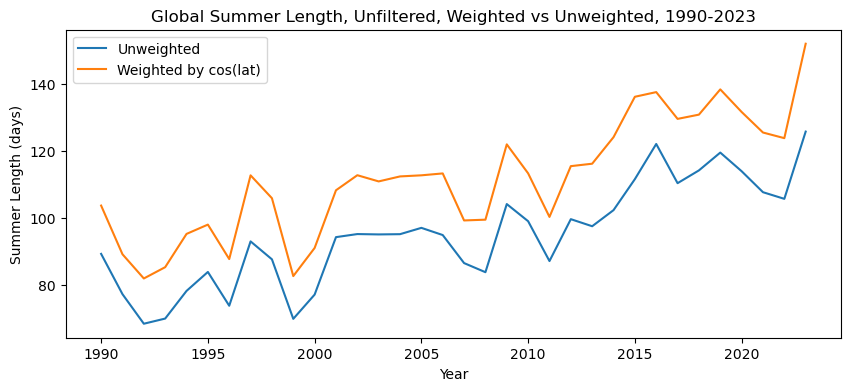

In [4]:
avg_glob_summ_length = ds.SummerLength.mean(dim=['lat','lon'])

# find weights (this is a regular grid so we can use cos(latitude))
weights = np.cos(np.deg2rad(ds.lat))
weights.name = "weights"
# take the weighted spatial mean since the latitude range of the region of interest is large
wavg_glob_summ_length = ds.SummerLength.weighted(weights).mean(dim=['lat','lon'])


plt.figure(figsize=(10,4))
plt.plot(avg_glob_summ_length.time.dt.year, avg_glob_summ_length, label="Unweighted")
plt.plot(wavg_glob_summ_length.time.dt.year, wavg_glob_summ_length, label="Weighted by cos(lat)")
plt.xlabel("Year")
plt.ylabel("Summer Length (days)")
plt.title("Global Summer Length, Unfiltered, Weighted vs Unweighted, 1990-2023")
plt.legend()
plt.show()

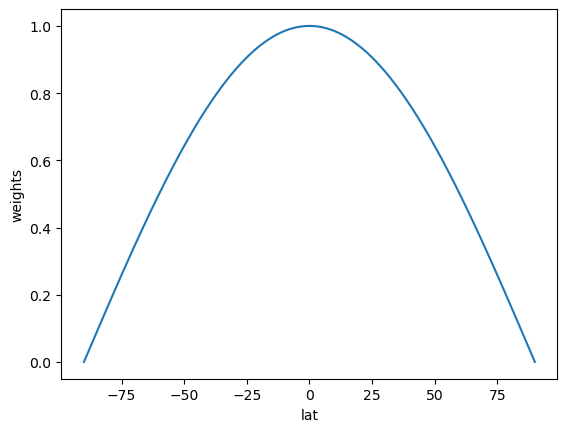

In [5]:
weights.plot()

### All remaining plots are weighted 

### Global Land vs Ocean Summer Length

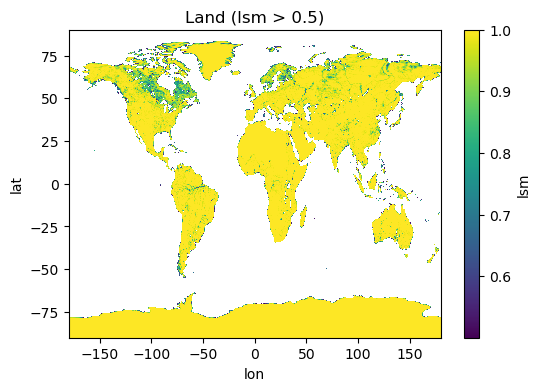

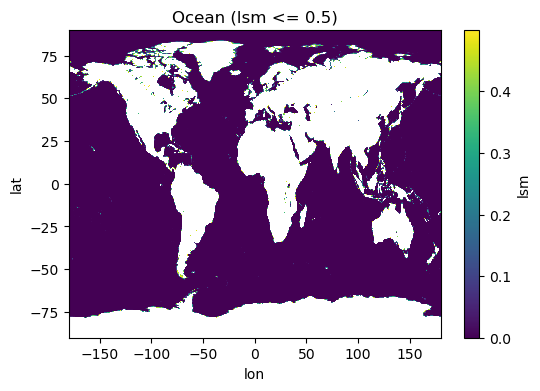

In [6]:
# can be land and inland small water
ds_land = ds.where(ds.lsm > 0.5)
ds_ocean = ds.where(ds.lsm <= 0.5)

plt.figure(figsize=(6,4))
#plt.subplot(111)
ds_land.lsm.sel(time='2020').plot()
plt.title("Land (lsm > 0.5)")
#plt.subplot(122)
plt.figure(figsize=(6,4))
ds_ocean.lsm.sel(time='2020').plot()
plt.title("Ocean (lsm <= 0.5)")
#plt.tight_layout()
plt.show()

In [7]:
ds_land

<xarray.Dataset> Size: 3GB
Dimensions:       (time: 34, lat: 721, lon: 1440)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time          (time) datetime64[ns] 272B 1990-01-01 ... 2023-01-01
Data variables:
    SummerStart   (time, lat, lon) float64 282MB 146.0 146.0 146.0 ... nan nan
    SummerEnd     (time, lat, lon) float64 282MB 220.0 220.0 220.0 ... nan nan
    SummerTmax    (time, lat, lon) float64 282MB 174.0 174.0 174.0 ... nan nan
    SummerHeat    (time, lat, lon) float64 282MB 663.9 663.9 663.9 ... nan nan
    SummerLength  (time, lat, lon) float64 282MB 75.0 75.0 75.0 ... nan nan nan
    SummerRMSE    (time, lat, lon) float64 282MB 7.937 7.937 7.937 ... nan nan
    SummerR2      (time, lat, lon) float64 282MB 0.5064 0.5064 ... nan nan
    SummerMeanT   (time, lat, lon) float64 282MB 245.3 245.3 245.3 ... nan nan
    SummerMeanHS  (time, lat, lon) float64 282MB 8.852 8.852 8.852 ... nan nan
    lsm           (time, lat, lon) float64 282MB 1.0 1.0 1.0 1.0 ... nan nan nan

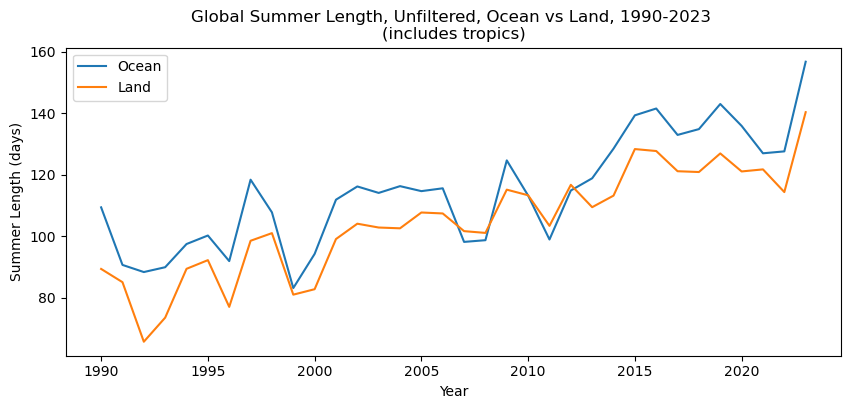

In [8]:


# take the weighted spatial mean since the latitude range of the region of interest is large
wavg_land_sl = ds_land.SummerLength.weighted(weights).mean(dim=['lat','lon'])
wavg_ocean_sl = ds_ocean.SummerLength.weighted(weights).mean(dim=['lat','lon'])

plt.figure(figsize=(10,4))
plt.plot(wavg_ocean_sl.time.dt.year, wavg_ocean_sl, label="Ocean")
plt.plot(wavg_land_sl.time.dt.year, wavg_land_sl, label="Land")

plt.xlabel("Year")
plt.ylabel("Summer Length (days)")
plt.title("Global Summer Length, Unfiltered, Ocean vs Land, 1990-2023 \n(includes tropics)")
plt.legend()
plt.show()

## Global Mid-latitude Land vs Ocean

<>:12: SyntaxWarning: invalid escape sequence '\c'
<>:12: SyntaxWarning: invalid escape sequence '\c'
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/1194900943.py:12: SyntaxWarning: invalid escape sequence '\c'
  plt.title("Global Midlatitude Summer Length, Unfiltered, Ocean vs Land, 1990-2023 \n[23.5, 70]$^\circ$N and [-70, -23]$^\circ$S")


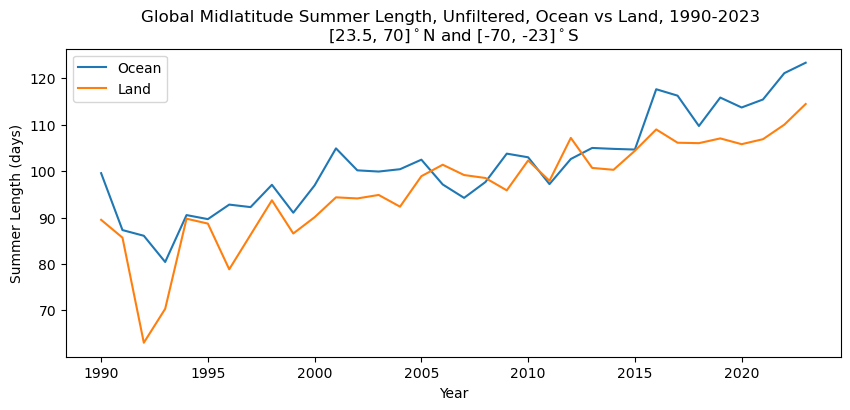

In [9]:
# take the weighted spatial mean since the latitude range of the region of interest is large
wavg_midlat_land_sl = ds_land.SummerLength.where(((ds_land.lat >= 23.5) & (ds_land.lat <= 70)) | 
                                         ((ds_land.lat <= -23.5) & (ds_land.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])
wavg_midlat_ocean_sl = ds_ocean.SummerLength.where(((ds_ocean.lat >= 23.5) & (ds_ocean.lat <= 70)) |
                                           ((ds_ocean.lat <= -23.5) & (ds_ocean.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])

plt.figure(figsize=(10,4))
plt.plot(wavg_midlat_ocean_sl.time.dt.year, wavg_midlat_ocean_sl, label="Ocean")
plt.plot(wavg_midlat_land_sl.time.dt.year, wavg_midlat_land_sl, label="Land")
plt.xlabel("Year")
plt.ylabel("Summer Length (days)")
plt.title("Global Midlatitude Summer Length, Unfiltered, Ocean vs Land, 1990-2023 \n[23.5, 70]$^\circ$N and [-70, -23]$^\circ$S")
plt.legend()
plt.show()

## NH vs SH Mid-latitude Land

<>:46: SyntaxWarning: invalid escape sequence '\p'
<>:50: SyntaxWarning: invalid escape sequence '\p'
<>:54: SyntaxWarning: invalid escape sequence '\c'
<>:46: SyntaxWarning: invalid escape sequence '\p'
<>:50: SyntaxWarning: invalid escape sequence '\p'
<>:54: SyntaxWarning: invalid escape sequence '\c'
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/149340315.py:46: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_nh)+" $\pm$ "+str(slope_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_nh))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/149340315.py:50: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_sh)+" $\pm$ "+str(slope_sh_sd)+" (days/yr), $R^2$ = "+str(r_squared_sh))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/149340315.py:54: SyntaxWarning: invalid escape sequence '\c'
  plt.title("Midlatitude Land Summer Length, Unfiltered, NH vs SH, 1990-2023 \n[23.5, 70]$^\circ$N or [-70, -23]

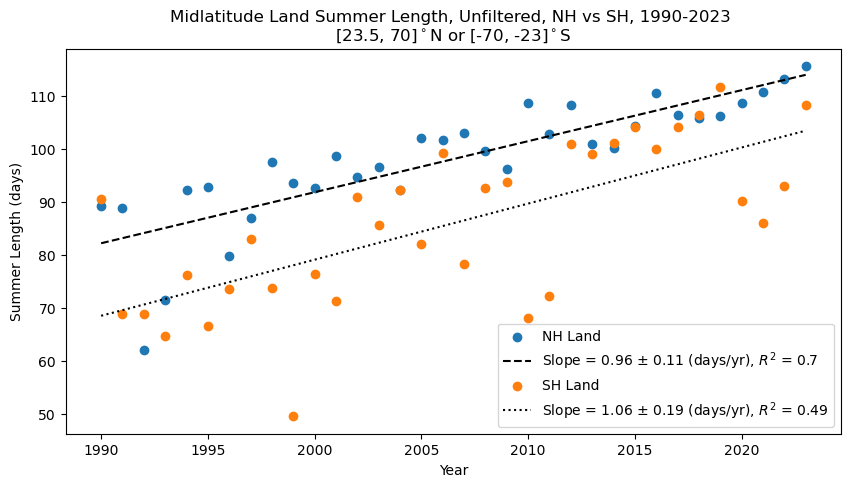

In [10]:
# take the weighted spatial mean since the latitude range of the region of interest is large

# NH
wavg_nh_land_sl = ds_land.SummerLength.where(((ds_land.lat >= 23.5) & (ds_land.lat <= 70))).weighted(weights).mean(dim=['lat','lon'])
x_nh = wavg_nh_land_sl.time.dt.year.values
y_nh = wavg_nh_land_sl.values

# linear fit
# error on slope via https://stackoverflow.com/questions/27634270/how-to-find-error-on-slope-and-intercept-using-numpy-polyfit
# error is stddev of 
coefs_nh, V = np.polyfit(x_nh, y_nh, 1, cov=True)
poly_nh = np.poly1d(coefs_nh)
slope_nh = np.round(coefs_nh[0],2)
slope_nh_sd = np.round(np.sqrt(V[0][0]),2)


# add in R^2 and RMSE
ymean = np.mean(y_nh)
ss_total = np.sum((y_nh - ymean)**2)
ss_res = np.sum((y_nh - poly_nh(x_nh))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_nh = np.round(1 - (ss_res / ss_total),2)

# SH
wavg_sh_land_sl = ds_land.SummerLength.where(((ds_land.lat <= -23.5) & (ds_land.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])
x_sh = wavg_sh_land_sl.time.dt.year.values
y_sh = wavg_sh_land_sl.values

# linear fit
coefs_sh, V = np.polyfit(x_sh, y_sh, 1, cov=True)
poly_sh = np.poly1d(coefs_sh)
slope_sh = np.round(coefs_sh[0],2)
slope_sh_sd = np.round(np.sqrt(V[0][0]),2)

# add in R^2 and RMSE
ymean = np.mean(y_sh)
ss_total = np.sum((y_sh - ymean)**2)
ss_res = np.sum((y_sh - poly_sh(x_sh))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_sh = np.round(1 - (ss_res / ss_total),2)


plt.figure(figsize=(10,5))
plt.scatter(wavg_nh_land_sl.time.dt.year, wavg_nh_land_sl, label="NH Land")
plt.plot(x_nh, poly_nh(x_nh), linestyle="dashed", color='k', 
         label="Slope = "+str(slope_nh)+" $\pm$ "+str(slope_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_nh))

plt.scatter(wavg_sh_land_sl.time.dt.year, wavg_sh_land_sl, label="SH Land")
plt.plot(x_sh, poly_sh(x_sh), linestyle="dotted", color='k',
         label="Slope = "+str(slope_sh)+" $\pm$ "+str(slope_sh_sd)+" (days/yr), $R^2$ = "+str(r_squared_sh))

plt.xlabel("Year")
plt.ylabel("Summer Length (days)")
plt.title("Midlatitude Land Summer Length, Unfiltered, NH vs SH, 1990-2023 \n[23.5, 70]$^\circ$N or [-70, -23]$^\circ$S")
plt.legend()
plt.show()

## NH vs SH Mid-latitude Ocean

<>:44: SyntaxWarning: invalid escape sequence '\p'
<>:48: SyntaxWarning: invalid escape sequence '\p'
<>:52: SyntaxWarning: invalid escape sequence '\c'
<>:44: SyntaxWarning: invalid escape sequence '\p'
<>:48: SyntaxWarning: invalid escape sequence '\p'
<>:52: SyntaxWarning: invalid escape sequence '\c'
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/1283831001.py:44: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_o_nh)+" $\pm$ "+str(slope_o_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_o_nh))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/1283831001.py:48: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_o_sh)+" $\pm$ "+str(slope_o_sh_sd)+" (days/yr), $R^2$ = "+str(r_squared_o_sh))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/1283831001.py:52: SyntaxWarning: invalid escape sequence '\c'
  plt.title("Midlatitude Ocean Summer Length, Unfiltered, NH vs SH, 1990-2023 \n[23.5, 70]$^\circ

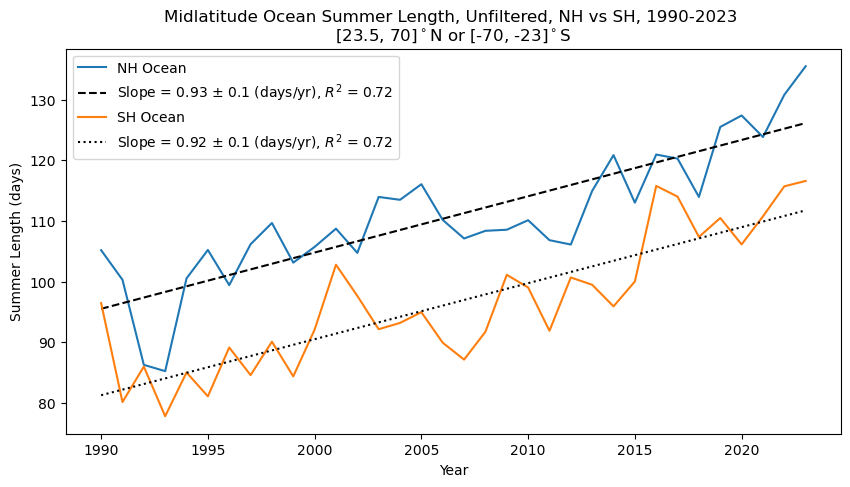

In [11]:
# NH
# get linear fits to the data and plot as well
wavg_nh_ocean_sl = ds_ocean.SummerLength.where(((ds_ocean.lat >= 23.5) & (ds_ocean.lat <= 70))).weighted(weights).mean(dim=['lat','lon'])
x_nh = wavg_nh_ocean_sl.time.dt.year.values
y_nh = wavg_nh_ocean_sl.values

# linear fit
# error on slope via https://stackoverflow.com/questions/27634270/how-to-find-error-on-slope-and-intercept-using-numpy-polyfit
# error is stddev of 
coefs_nh, V = np.polyfit(x_nh, y_nh, 1, cov=True)
poly_o_nh = np.poly1d(coefs_nh)
slope_o_nh = np.round(coefs_nh[0],2)
slope_o_nh_sd = np.round(np.sqrt(V[0][0]),2)

# add in R^2 and RMSE
ymean = np.mean(y_nh)
ss_total = np.sum((y_nh - ymean)**2)
ss_res = np.sum((y_nh - poly_o_nh(x_nh))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_o_nh = np.round(1 - (ss_res / ss_total),2)

# SH
wavg_sh_ocean_sl = ds_ocean.SummerLength.where(((ds_ocean.lat <= -23.5) & (ds_ocean.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])
x_sh = wavg_sh_ocean_sl.time.dt.year.values
y_sh = wavg_sh_ocean_sl.values

# linear fit
coefs_sh, V = np.polyfit(x_sh, y_sh, 1, cov=True)
poly_o_sh = np.poly1d(coefs_sh)
slope_o_sh = np.round(coefs_sh[0],2)
slope_o_sh_sd = np.round(np.sqrt(V[0][0]),2)

# add in R^2 and RMSE
ymean = np.mean(y_sh)
ss_total = np.sum((y_sh - ymean)**2)
ss_res = np.sum((y_sh - poly_o_sh(x_sh))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_o_sh = np.round(1 - (ss_res / ss_total),2)


plt.figure(figsize=(10,5))
plt.plot(wavg_nh_ocean_sl.time.dt.year, wavg_nh_ocean_sl, label="NH Ocean")
plt.plot(x_nh, poly_o_nh(x_nh), linestyle="dashed", color='k', 
         label="Slope = "+str(slope_o_nh)+" $\pm$ "+str(slope_o_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_o_nh))

plt.plot(wavg_sh_ocean_sl.time.dt.year, wavg_sh_ocean_sl, label="SH Ocean")
plt.plot(x_sh, poly_o_sh(x_sh), linestyle="dotted", color='k', 
         label="Slope = "+str(slope_o_sh)+" $\pm$ "+str(slope_o_sh_sd)+" (days/yr), $R^2$ = "+str(r_squared_o_sh))

plt.xlabel("Year")
plt.ylabel("Summer Length (days)")
plt.title("Midlatitude Ocean Summer Length, Unfiltered, NH vs SH, 1990-2023 \n[23.5, 70]$^\circ$N or [-70, -23]$^\circ$S")
plt.legend()
plt.show()

## NH Mid-latitude Ocean vs Land

<>:4: SyntaxWarning: invalid escape sequence '\p'
<>:7: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\c'
<>:4: SyntaxWarning: invalid escape sequence '\p'
<>:7: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\c'
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/3678214715.py:4: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_o_nh)+" $\pm$ "+str(slope_o_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_o_nh))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/3678214715.py:7: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_nh)+" $\pm$ "+str(slope_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_nh))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/3678214715.py:10: SyntaxWarning: invalid escape sequence '\c'
  plt.title("NH Midlatitude Summer Length, Unfiltered, Ocean vs Land, 1990-2023 \n[23.5, 70]$^\circ$N")


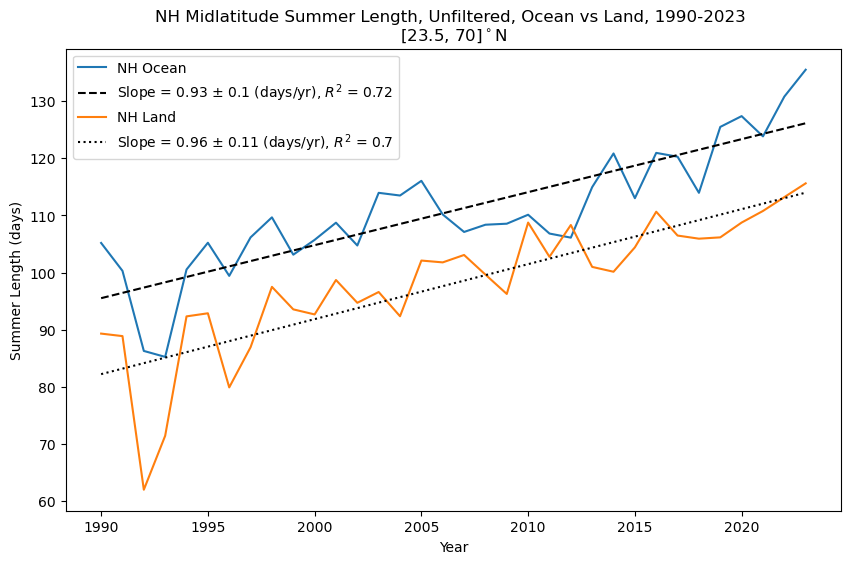

In [12]:

plt.figure(figsize=(10,6))
plt.plot(wavg_nh_ocean_sl.time.dt.year, wavg_nh_ocean_sl, label="NH Ocean")
plt.plot(x_nh, poly_o_nh(x_nh), linestyle="dashed", color='k', 
         label="Slope = "+str(slope_o_nh)+" $\pm$ "+str(slope_o_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_o_nh))
plt.plot(wavg_nh_land_sl.time.dt.year, wavg_nh_land_sl, label="NH Land")
plt.plot(x_nh, poly_nh(x_nh), linestyle="dotted", color='k', 
         label="Slope = "+str(slope_nh)+" $\pm$ "+str(slope_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_nh))
plt.xlabel("Year")
plt.ylabel("Summer Length (days)")
plt.title("NH Midlatitude Summer Length, Unfiltered, Ocean vs Land, 1990-2023 \n[23.5, 70]$^\circ$N")
plt.legend()
plt.show()

## SH Mid-latitude Ocean vs Land

<>:4: SyntaxWarning: invalid escape sequence '\p'
<>:8: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\c'
<>:4: SyntaxWarning: invalid escape sequence '\p'
<>:8: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\c'
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/3297307256.py:4: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_o_sh)+" $\pm$ "+str(slope_o_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_o_sh))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/3297307256.py:8: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_sh)+" $\pm$ "+str(slope_sh_sd)+" (days/yr), $R^2$ = "+str(r_squared_sh))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/3297307256.py:11: SyntaxWarning: invalid escape sequence '\c'
  plt.title("SH Midlatitude Summer Length, Unfiltered, Ocean vs Land, 1990-2023 \n[-70, -23]$^\circ$S")


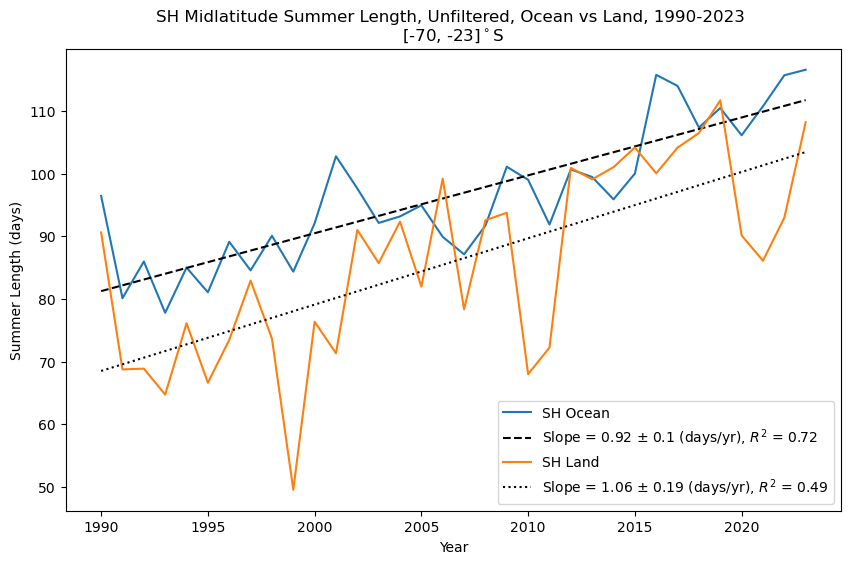

In [13]:

plt.figure(figsize=(10,6))
plt.plot(wavg_sh_ocean_sl.time.dt.year, wavg_sh_ocean_sl, label="SH Ocean")
plt.plot(x_sh, poly_o_sh(x_sh), linestyle="dashed", color='k', 
         label="Slope = "+str(slope_o_sh)+" $\pm$ "+str(slope_o_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_o_sh))

plt.plot(wavg_sh_land_sl.time.dt.year, wavg_sh_land_sl, label="SH Land")
plt.plot(x_sh, poly_sh(x_sh), linestyle="dotted", color='k',
         label="Slope = "+str(slope_sh)+" $\pm$ "+str(slope_sh_sd)+" (days/yr), $R^2$ = "+str(r_squared_sh))
plt.xlabel("Year")
plt.ylabel("Summer Length (days)")
plt.title("SH Midlatitude Summer Length, Unfiltered, Ocean vs Land, 1990-2023 \n[-70, -23]$^\circ$S")
plt.legend()
plt.show()

## Load in baseline years (1961-1990) to see longer term trend and compare to prior works like Wang et al (2021) and Lin & Wang (2022)

In [14]:
%%time

# takes ~50 sec to load

# start with one year and lsm and add a coordinate for the year
year = 1961
input_path = '../../../Data/ERA5-global/Analysis/New/'+str(year)+'_summer_stats.nc'
ds_base = xr.open_dataset(input_path)
ds_base = ds_base.merge(ds_lsm)
ds_base = ds_base.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))

# loop thru remaining years and also add time coord
input_years = np.arange(1962,1991,1)

for year in input_years:
    input_path = '../../../Data/ERA5-global/Analysis/New/'+str(year)+'_summer_stats.nc'
    ds_i = xr.open_dataset(input_path)
    ds_i = ds_i.merge(ds_lsm)
    ds_i = ds_i.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))
    ds_base = ds_base.merge(ds_i)

ds_base

CPU times: user 19.4 s, sys: 27.5 s, total: 46.8 s
Wall time: 55.7 s


<xarray.Dataset> Size: 2GB
Dimensions:       (lat: 721, lon: 1440, time: 30)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time          (time) datetime64[ns] 240B 1961-01-01 ... 1990-01-01
Data variables:
    SummerStart   (time, lat, lon) float64 249MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    SummerEnd     (time, lat, lon) float64 249MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    SummerTmax    (time, lat, lon) float64 249MB 179.0 179.0 ... 203.0 203.0
    SummerHeat    (time, lat, lon) float64 249MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    SummerLength  (time, lat, lon) float64 249MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    SummerRMSE    (time, lat, lon) float64 249MB 6.906 6.906 ... 5.745 5.745
    SummerR2      (time, lat, lon) float64 249MB 0.5105 0.5105 ... 0.6524 0.6524
    SummerMeanT   (time, lat, lon) float64 249MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    SummerMeanHS  (time, lat, lon) float64 249MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    lsm           (time, lat, lon) float64 249MB 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0

### Weight by cos(lat) for global mean Summer length per baseline years

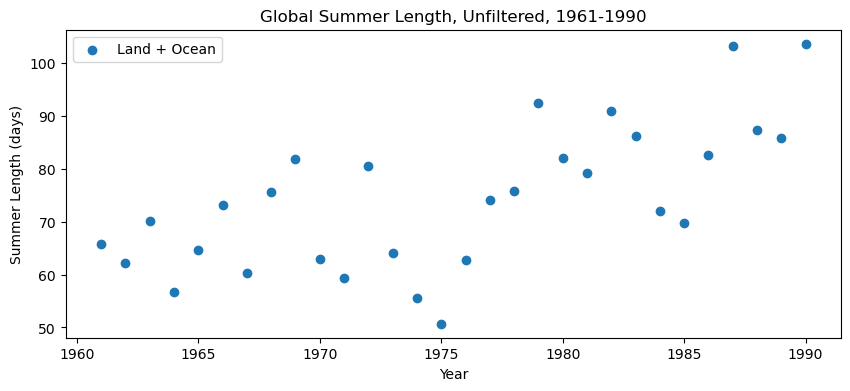

In [15]:
# find weights (this is a regular grid so we can use cos(latitude))
weights = np.cos(np.deg2rad(ds_base.lat))
weights.name = "weights"
# take the weighted spatial mean since the latitude range of the region of interest is large
wavg_glob_summ_length_base = ds_base.SummerLength.weighted(weights).mean(dim=['lat','lon'])

plt.figure(figsize=(10,4))
#plt.plot(avg_glob_summ_length.time.dt.year, avg_glob_summ_length, label="Unweighted")
plt.scatter(wavg_glob_summ_length_base.time.dt.year, wavg_glob_summ_length_base, label="Land + Ocean")
plt.xlabel("Year")
plt.ylabel("Summer Length (days)")
plt.title("Global Summer Length, Unfiltered, 1961-1990")
plt.legend()
plt.show()

### Split baseline years into Land vs Ocean

In [16]:
ds_base_land = ds_base.where(ds_base.lsm > 0.5)
ds_base_ocean = ds_base.where(ds_base.lsm <= 0.5)

<>:14: SyntaxWarning: invalid escape sequence '\c'
<>:14: SyntaxWarning: invalid escape sequence '\c'
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/103663282.py:14: SyntaxWarning: invalid escape sequence '\c'
  plt.title("Global Midlatitude Summer Length, Unfiltered, Ocean vs Land, 1961-2023 \n[23.5, 70]$^\circ$N and [-70, -23]$^\circ$S")


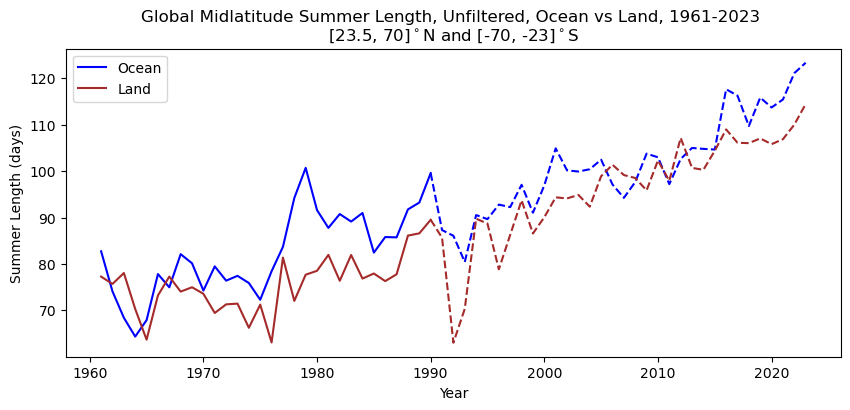

In [17]:
# take the weighted spatial mean since the latitude range of the region of interest is large
wavg_midlat_land_sl_base = ds_base_land.SummerLength.where(((ds_base_land.lat >= 23.5) & (ds_base_land.lat <= 70)) | 
                                         ((ds_base_land.lat <= -23.5) & (ds_base_land.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])
wavg_midlat_ocean_sl_base = ds_base_ocean.SummerLength.where(((ds_base_ocean.lat >= 23.5) & (ds_base_ocean.lat <= 70)) |
                                           ((ds_base_ocean.lat <= -23.5) & (ds_base_ocean.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])

plt.figure(figsize=(10,4))
plt.plot(wavg_midlat_ocean_sl_base.time.dt.year, wavg_midlat_ocean_sl_base, label="Ocean", color="blue")
plt.plot(wavg_midlat_land_sl_base.time.dt.year, wavg_midlat_land_sl_base, label="Land", color="brown")
plt.plot(wavg_midlat_ocean_sl.time.dt.year, wavg_midlat_ocean_sl, label="", linestyle="--", color="blue")
plt.plot(wavg_midlat_land_sl.time.dt.year, wavg_midlat_land_sl, label="", linestyle="--", color="brown")
plt.xlabel("Year")
plt.ylabel("Summer Length (days)")
plt.title("Global Midlatitude Summer Length, Unfiltered, Ocean vs Land, 1961-2023 \n[23.5, 70]$^\circ$N and [-70, -23]$^\circ$S")
plt.legend()
plt.show()

In [18]:
ds_full_land = ds_base_land.merge(ds_land)
ds_full_land

<xarray.Dataset> Size: 5GB
Dimensions:       (lat: 721, lon: 1440, time: 63)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time          (time) datetime64[ns] 504B 1961-01-01 ... 2023-01-01
Data variables:
    SummerStart   (time, lat, lon) float64 523MB 0.0 0.0 0.0 0.0 ... nan nan nan
    SummerEnd     (time, lat, lon) float64 523MB 0.0 0.0 0.0 0.0 ... nan nan nan
    SummerTmax    (time, lat, lon) float64 523MB 179.0 179.0 179.0 ... nan nan
    SummerHeat    (time, lat, lon) float64 523MB 0.0 0.0 0.0 0.0 ... nan nan nan
    SummerLength  (time, lat, lon) float64 523MB 0.0 0.0 0.0 0.0 ... nan nan nan
    SummerRMSE    (time, lat, lon) float64 523MB 6.906 6.906 6.906 ... nan nan
    SummerR2      (time, lat, lon) float64 523MB 0.5105 0.5105 ... nan nan
    SummerMeanT   (time, lat, lon) float64 523MB 0.0 0.0 0.0 0.0 ... nan nan nan
    SummerMeanHS  (time, lat, lon) float64 523MB 0.0 0.0 0.0 0.0 ... nan nan nan
    lsm           (time, lat, lon) float64 523MB 1.0 1.0 1.0 1.0 ... nan nan nan

In [19]:
ds_full_ocean = ds_base_ocean.merge(ds_ocean)
ds_full_ocean

<xarray.Dataset> Size: 5GB
Dimensions:       (lat: 721, lon: 1440, time: 63)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time          (time) datetime64[ns] 504B 1961-01-01 ... 2023-01-01
Data variables:
    SummerStart   (time, lat, lon) float64 523MB nan nan nan ... 216.0 216.0
    SummerEnd     (time, lat, lon) float64 523MB nan nan nan ... 247.0 247.0
    SummerTmax    (time, lat, lon) float64 523MB nan nan nan ... 231.0 231.0
    SummerHeat    (time, lat, lon) float64 523MB nan nan nan ... 69.28 69.28
    SummerLength  (time, lat, lon) float64 523MB nan nan nan ... 32.0 32.0 32.0
    SummerRMSE    (time, lat, lon) float64 523MB nan nan nan ... 5.387 5.387
    SummerR2      (time, lat, lon) float64 523MB nan nan nan ... 0.735 0.735
    SummerMeanT   (time, lat, lon) float64 523MB nan nan nan ... 272.9 272.9
    SummerMeanHS  (time, lat, lon) float64 523MB nan nan nan ... 2.165 2.165
    lsm           (time, lat, lon) float64 523MB nan nan nan nan ... 0.0 0.0 0.0

In [43]:
# re-add attributes which get lost on merge apparently
ds_full_land.SummerStart.attrs["long_name"] = "Start day of summer for the year (DOY in [1,365])"
ds_full_land.SummerStart.attrs["units"] = "Day of year"

ds_full_land.SummerEnd.attrs["long_name"] = "Last day of summer for the year (DOY in [1,365])"
ds_full_land.SummerEnd.attrs["units"] = "Day of year"

ds_full_land.SummerLength.attrs["long_name"] = "Duration of summer for the year"
ds_full_land.SummerLength.attrs["units"] = "Days"

ds_full_land.SummerTmax.attrs["long_name"] = "Day of max mean temp during summer for the year"
ds_full_land.SummerTmax.attrs["units"] = "Day of year"

ds_full_land.SummerHeat.attrs["long_name"] = "Accumulated heat during summer for the year"
ds_full_land.SummerHeat.attrs["units"] = "Degree-Days"

ds_full_land.SummerRMSE.attrs["long_name"] = "Root mean squared error of polynomial fit"
ds_full_land.SummerRMSE.attrs["units"] = "Degrees [K]"

ds_full_land.SummerR2.attrs["long_name"] = "Coefficient of determination (R-squared) of polynomial fit"
ds_full_land.SummerR2.attrs["units"] = "Variance explained"

ds_full_land.SummerMeanT.attrs["long_name"] = "Mean temperature during the summer period"
ds_full_land.SummerMeanT.attrs["units"] = "Degrees [K]"

ds_full_land.lsm.attrs["long_name"] = "Land-sea mask"
ds_full_land.lsm.attrs["units"] = "(0 - 1)"

ds_full_land.SummerMeanHS.attrs["long_name"] = "Mean HS temperature during the summer period"
ds_full_land.SummerMeanHS.attrs["units"] = "Degrees [K]"

ds_full_ocean.SummerStart.attrs["long_name"] = "Start day of summer for the year (DOY in [1,365])"
ds_full_ocean.SummerStart.attrs["units"] = "Day of year"

ds_full_ocean.SummerEnd.attrs["long_name"] = "Last day of summer for the year (DOY in [1,365])"
ds_full_ocean.SummerEnd.attrs["units"] = "Day of year"

ds_full_ocean.SummerLength.attrs["long_name"] = "Duration of summer for the year"
ds_full_ocean.SummerLength.attrs["units"] = "Days"

ds_full_ocean.SummerTmax.attrs["long_name"] = "Day of max mean temp during summer for the year"
ds_full_ocean.SummerTmax.attrs["units"] = "Day of year"

ds_full_ocean.SummerHeat.attrs["long_name"] = "Accumulated heat during summer for the year"
ds_full_ocean.SummerHeat.attrs["units"] = "Degree-Days"

ds_full_ocean.SummerRMSE.attrs["long_name"] = "Root mean squared error of polynomial fit"
ds_full_ocean.SummerRMSE.attrs["units"] = "Degrees [K]"

ds_full_ocean.SummerR2.attrs["long_name"] = "Coefficient of determination (R-squared) of polynomial fit"
ds_full_ocean.SummerR2.attrs["units"] = "Variance explained"

ds_full_ocean.SummerMeanT.attrs["long_name"] = "Mean temperature during the summer period"
ds_full_ocean.SummerMeanT.attrs["units"] = "Degrees [K]"

ds_full_ocean.lsm.attrs["long_name"] = "Land-sea mask"
ds_full_ocean.lsm.attrs["units"] = "(0 - 1)"

ds_full_ocean.SummerMeanHS.attrs["long_name"] = "Mean HS temperature during the summer period"
ds_full_ocean.SummerMeanHS.attrs["units"] = "Degrees [K]"



In [44]:
ds_full_land

<xarray.Dataset> Size: 5GB
Dimensions:       (lat: 721, lon: 1440, time: 63)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time          (time) datetime64[ns] 504B 1961-01-01 ... 2023-01-01
Data variables:
    SummerStart   (time, lat, lon) float64 523MB 0.0 0.0 0.0 0.0 ... nan nan nan
    SummerEnd     (time, lat, lon) float64 523MB 0.0 0.0 0.0 0.0 ... nan nan nan
    SummerTmax    (time, lat, lon) float64 523MB 179.0 179.0 179.0 ... nan nan
    SummerHeat    (time, lat, lon) float64 523MB 0.0 0.0 0.0 0.0 ... nan nan nan
    SummerLength  (time, lat, lon) float64 523MB 0.0 0.0 0.0 0.0 ... nan nan nan
    SummerRMSE    (time, lat, lon) float64 523MB 6.906 6.906 6.906 ... nan nan
    SummerR2      (time, lat, lon) float64 523MB 0.5105 0.5105 ... nan nan
    SummerMeanT   (time, lat, lon) float64 523MB 0.0 0.0 0.0 0.0 ... nan nan nan
    SummerMeanHS  (time, lat, lon) float64 523MB 0.0 0.0 0.0 0.0 ... nan nan nan
    lsm           (time, lat, lon) float64 523MB 1.0 1.0 1.0 1.0 ... nan nan nan

## <br> <span style="color:red">WRITE OUT THE LAND AND OCEAN FULL DATASETS</span>

In [21]:
# write that out for later use
output_path = '../../../Data/ERA5-global/Analysis/New/1961-2023_LAND_summer_stats.nc'
ds_full_land.to_netcdf(output_path)

output_path2 = '../../../Data/ERA5-global/Analysis/New/1961-2023_OCEAN_summer_stats.nc'
ds_full_ocean.to_netcdf(output_path2)



### NH and SH Mid-latitude Summer Length for LAND over period (1961-2012) to compare to prior works

<>:56: SyntaxWarning: invalid escape sequence '\p'
<>:60: SyntaxWarning: invalid escape sequence '\p'
<>:67: SyntaxWarning: invalid escape sequence '\c'
<>:56: SyntaxWarning: invalid escape sequence '\p'
<>:60: SyntaxWarning: invalid escape sequence '\p'
<>:67: SyntaxWarning: invalid escape sequence '\c'
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/1536757493.py:56: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_nh)+" $\pm$ "+str(slope_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_nh))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/1536757493.py:60: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_sh)+" $\pm$ "+str(slope_sh_sd)+" (days/yr), $R^2$ = "+str(r_squared_sh))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/1536757493.py:67: SyntaxWarning: invalid escape sequence '\c'
  plt.title("Midlatitude Land Summer Length, Unfiltered, NH vs SH, 1961-2012 \n[23.5, 70]$^\circ$N or [-70, -

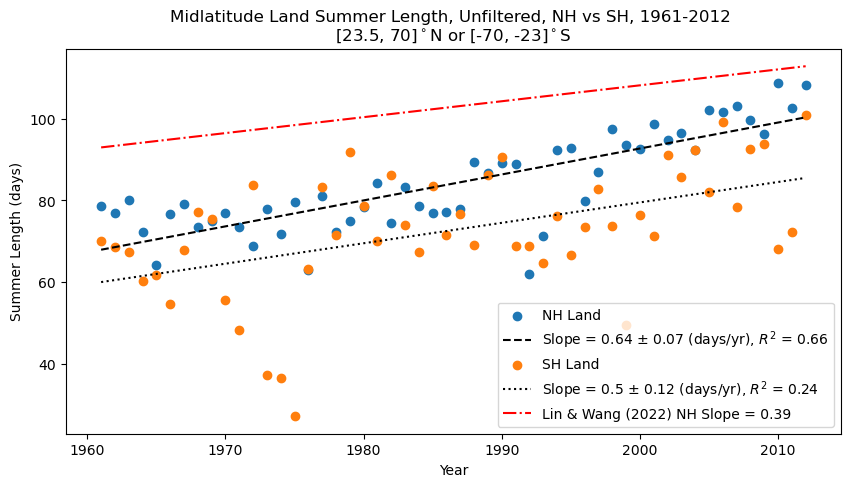

In [22]:
# take the weighted spatial mean since the latitude range of the region of interest is large

# NH
wavg_nh_land_sl = ds_full_land.SummerLength.where(((ds_full_land.lat >= 23.5) & (ds_full_land.lat <= 70))).weighted(weights).mean(dim=['lat','lon'])

# filter to 1961-2012
wavg_nh_land_sl = wavg_nh_land_sl.sel(time=slice('1961','2012'))

# x & y
x_nh = wavg_nh_land_sl.time.dt.year.values
y_nh = wavg_nh_land_sl.values

# linear fit
# error on slope via https://stackoverflow.com/questions/27634270/how-to-find-error-on-slope-and-intercept-using-numpy-polyfit
# error is stddev of 
coefs_nh, V = np.polyfit(x_nh, y_nh, 1, cov=True)
poly_nh = np.poly1d(coefs_nh)
slope_nh = np.round(coefs_nh[0],2)
slope_nh_sd = np.round(np.sqrt(V[0][0]),2)


# add in R^2 and RMSE
ymean = np.mean(y_nh)
ss_total = np.sum((y_nh - ymean)**2)
ss_res = np.sum((y_nh - poly_nh(x_nh))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_nh = np.round(1 - (ss_res / ss_total),2)

# SH
wavg_sh_land_sl = ds_full_land.SummerLength.where(((ds_full_land.lat <= -23.5) & (ds_full_land.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])

# filter to 1961-2012
wavg_sh_land_sl = wavg_sh_land_sl.sel(time=slice('1961','2012'))

# x & y
x_sh = wavg_sh_land_sl.time.dt.year.values
y_sh = wavg_sh_land_sl.values

# linear fit
coefs_sh, V = np.polyfit(x_sh, y_sh, 1, cov=True)
poly_sh = np.poly1d(coefs_sh)
slope_sh = np.round(coefs_sh[0],2)
slope_sh_sd = np.round(np.sqrt(V[0][0]),2)

# add in R^2 and RMSE
ymean = np.mean(y_sh)
ss_total = np.sum((y_sh - ymean)**2)
ss_res = np.sum((y_sh - poly_sh(x_sh))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_sh = np.round(1 - (ss_res / ss_total),2)


plt.figure(figsize=(10,5))
plt.scatter(wavg_nh_land_sl.time.dt.year, wavg_nh_land_sl, label="NH Land")
plt.plot(x_nh, poly_nh(x_nh), linestyle="dashed", color='k', 
         label="Slope = "+str(slope_nh)+" $\pm$ "+str(slope_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_nh))

plt.scatter(wavg_sh_land_sl.time.dt.year, wavg_sh_land_sl, label="SH Land")
plt.plot(x_sh, poly_sh(x_sh), linestyle="dotted", color='k',
         label="Slope = "+str(slope_sh)+" $\pm$ "+str(slope_sh_sd)+" (days/yr), $R^2$ = "+str(r_squared_sh))

# add Fit from Lin & Wang 2022
plt.plot(x_nh, 0.39*(x_nh - 1961) + 93, linestyle="-.", color='r', label = "Lin & Wang (2022) NH Slope = 0.39")

plt.xlabel("Year")
plt.ylabel("Summer Length (days)")
plt.title("Midlatitude Land Summer Length, Unfiltered, NH vs SH, 1961-2012 \n[23.5, 70]$^\circ$N or [-70, -23]$^\circ$S")
plt.legend()
plt.show()

### Hmm, might be influenced by some of our poor $R^2$ cells so as a quick test of sensitivity, only use cells with $R^{2} \geq 0.5$

<>:60: SyntaxWarning: invalid escape sequence '\p'
<>:64: SyntaxWarning: invalid escape sequence '\p'
<>:68: SyntaxWarning: invalid escape sequence '\g'
<>:60: SyntaxWarning: invalid escape sequence '\p'
<>:64: SyntaxWarning: invalid escape sequence '\p'
<>:68: SyntaxWarning: invalid escape sequence '\g'
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/2122355223.py:60: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_nh)+" $\pm$ "+str(slope_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_nh))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/2122355223.py:64: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_sh)+" $\pm$ "+str(slope_sh_sd)+" (days/yr), $R^2$ = "+str(r_squared_sh))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/2122355223.py:68: SyntaxWarning: invalid escape sequence '\g'
  plt.title("Midlatitude Land Summer Length, $R^{2} \geq 0.5$, NH vs SH, 1961-2012 \n[23.5, 70]$^\circ$N or [

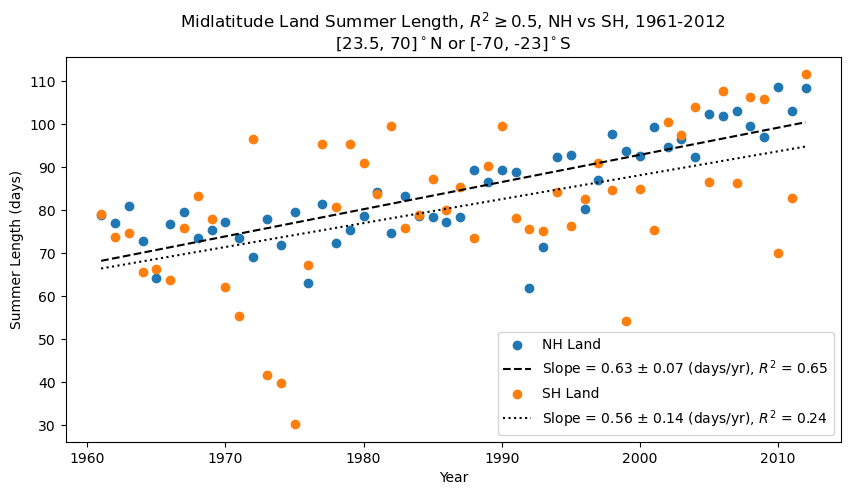

In [23]:
# filter land data to only cells with R^2 > 0.5
ds_full_land_filt = ds_full_land.where(ds_full_land.SummerR2 >= 0.5)


# take the weighted spatial mean since the latitude range of the region of interest is large

# NH
wavg_nh_land_sl = ds_full_land_filt.SummerLength.where(((ds_full_land_filt.lat >= 23.5) & (ds_full_land_filt.lat <= 70))).weighted(weights).mean(dim=['lat','lon'])

# filter to 1961-2014 - same as Lin & Wang 2022
wavg_nh_land_sl = wavg_nh_land_sl.sel(time=slice('1961','2012'))

# x & y
x_nh = wavg_nh_land_sl.time.dt.year.values
y_nh = wavg_nh_land_sl.values

# linear fit
# error on slope via https://stackoverflow.com/questions/27634270/how-to-find-error-on-slope-and-intercept-using-numpy-polyfit
# error is stddev of 
coefs_nh, V = np.polyfit(x_nh, y_nh, 1, cov=True)
poly_nh = np.poly1d(coefs_nh)
slope_nh = np.round(coefs_nh[0],2)
slope_nh_sd = np.round(np.sqrt(V[0][0]),2)


# add in R^2 and RMSE
ymean = np.mean(y_nh)
ss_total = np.sum((y_nh - ymean)**2)
ss_res = np.sum((y_nh - poly_nh(x_nh))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_nh = np.round(1 - (ss_res / ss_total),2)

# SH
wavg_sh_land_sl = ds_full_land_filt.SummerLength.where(((ds_full_land_filt.lat <= -23.5) & (ds_full_land_filt.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])

# filter to 1961-2012
wavg_sh_land_sl = wavg_sh_land_sl.sel(time=slice('1961','2012'))

# x & y
x_sh = wavg_sh_land_sl.time.dt.year.values
y_sh = wavg_sh_land_sl.values

# linear fit
coefs_sh, V = np.polyfit(x_sh, y_sh, 1, cov=True)
poly_sh = np.poly1d(coefs_sh)
slope_sh = np.round(coefs_sh[0],2)
slope_sh_sd = np.round(np.sqrt(V[0][0]),2)

# add in R^2 and RMSE
ymean = np.mean(y_sh)
ss_total = np.sum((y_sh - ymean)**2)
ss_res = np.sum((y_sh - poly_sh(x_sh))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_sh = np.round(1 - (ss_res / ss_total),2)


plt.figure(figsize=(10,5))
plt.scatter(wavg_nh_land_sl.time.dt.year, wavg_nh_land_sl, label="NH Land")
plt.plot(x_nh, poly_nh(x_nh), linestyle="dashed", color='k', 
         label="Slope = "+str(slope_nh)+" $\pm$ "+str(slope_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_nh))

plt.scatter(wavg_sh_land_sl.time.dt.year, wavg_sh_land_sl, label="SH Land")
plt.plot(x_sh, poly_sh(x_sh), linestyle="dotted", color='k',
         label="Slope = "+str(slope_sh)+" $\pm$ "+str(slope_sh_sd)+" (days/yr), $R^2$ = "+str(r_squared_sh))

plt.xlabel("Year")
plt.ylabel("Summer Length (days)")
plt.title("Midlatitude Land Summer Length, $R^{2} \geq 0.5$, NH vs SH, 1961-2012 \n[23.5, 70]$^\circ$N or [-70, -23]$^\circ$S")
plt.legend()
plt.show()

### <br><br>Essentially the same SLOPE results with and without the $R^2$ filter which is a promising sign, but would be good to have an explanation for why Lin & Wang have higher absolute numbers for the NH. Is it purely the smoothing method, or did they NOT weight their data by cell area? Test what unweighted NH vs weighted NH look like:<br><br>

<>:58: SyntaxWarning: invalid escape sequence '\p'
<>:62: SyntaxWarning: invalid escape sequence '\p'
<>:69: SyntaxWarning: invalid escape sequence '\c'
<>:58: SyntaxWarning: invalid escape sequence '\p'
<>:62: SyntaxWarning: invalid escape sequence '\p'
<>:69: SyntaxWarning: invalid escape sequence '\c'
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/3499950424.py:58: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_nh)+" $\pm$ "+str(slope_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_nh))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/3499950424.py:62: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_nhu)+" $\pm$ "+str(slope_nhu_sd)+" (days/yr), $R^2$ = "+str(r_squared_nhu))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/3499950424.py:69: SyntaxWarning: invalid escape sequence '\c'
  plt.title("Midlatitude Land Summer Length, Unfiltered, NH Weighted vs Unweighted, 1961-2012 \n[23.5, 70]

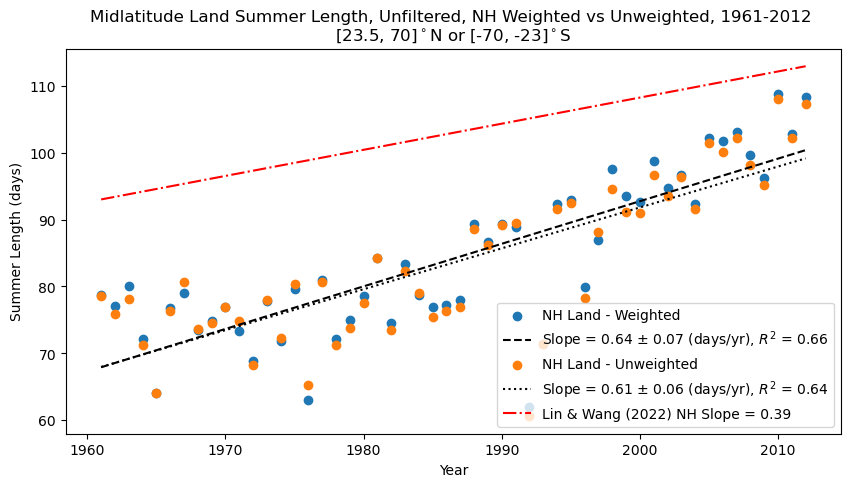

In [24]:

# NH WEIGHTED
wavg_nh_land_sl = ds_full_land.SummerLength.where(((ds_full_land.lat >= 23.5) & (ds_full_land.lat <= 70))).weighted(weights).mean(dim=['lat','lon'])

# filter to 1961-2012
wavg_nh_land_sl = wavg_nh_land_sl.sel(time=slice('1961','2012'))

# x & y
x_nh = wavg_nh_land_sl.time.dt.year.values
y_nh = wavg_nh_land_sl.values

# linear fit
# error on slope via https://stackoverflow.com/questions/27634270/how-to-find-error-on-slope-and-intercept-using-numpy-polyfit
# error is stddev of 
coefs_nh, V = np.polyfit(x_nh, y_nh, 1, cov=True)
poly_nh = np.poly1d(coefs_nh)
slope_nh = np.round(coefs_nh[0],2)
slope_nh_sd = np.round(np.sqrt(V[0][0]),2)


# add in R^2 and RMSE
ymean = np.mean(y_nh)
ss_total = np.sum((y_nh - ymean)**2)
ss_res = np.sum((y_nh - poly_nh(x_nh))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_nh = np.round(1 - (ss_res / ss_total),2)

# NH UNWEIGHTED
unwavg_nh_land_sl = ds_full_land.SummerLength.where(((ds_full_land.lat >= 23.5) & (ds_full_land.lat <= 70))).mean(dim=['lat','lon'])

# filter to 1961-2012
unwavg_nh_land_sl = unwavg_nh_land_sl.sel(time=slice('1961','2012'))

# x & y
x_nhu = unwavg_nh_land_sl.time.dt.year.values
y_nhu = unwavg_nh_land_sl.values

# linear fit
# error on slope via https://stackoverflow.com/questions/27634270/how-to-find-error-on-slope-and-intercept-using-numpy-polyfit
# error is stddev of 
coefs_nhu, V = np.polyfit(x_nhu, y_nhu, 1, cov=True)
poly_nhu = np.poly1d(coefs_nhu)
slope_nhu = np.round(coefs_nhu[0],2)
slope_nhu_sd = np.round(np.sqrt(V[0][0]),2)


# add in R^2 and RMSE
ymean = np.mean(y_nhu)
ss_total = np.sum((y_nhu - ymean)**2)
ss_res = np.sum((y_nhu - poly_nhu(x_nhu))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_nhu = np.round(1 - (ss_res / ss_total),2)



plt.figure(figsize=(10,5))
plt.scatter(wavg_nh_land_sl.time.dt.year, wavg_nh_land_sl, label="NH Land - Weighted")
plt.plot(x_nh, poly_nh(x_nh), linestyle="dashed", color='k', 
         label="Slope = "+str(slope_nh)+" $\pm$ "+str(slope_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_nh))

plt.scatter(unwavg_nh_land_sl.time.dt.year, unwavg_nh_land_sl, label="NH Land - Unweighted")
plt.plot(x_nhu, poly_nhu(x_nhu), linestyle="dotted", color='k',
         label="Slope = "+str(slope_nhu)+" $\pm$ "+str(slope_nhu_sd)+" (days/yr), $R^2$ = "+str(r_squared_nhu))

# add Fit from Lin & Wang 2022
plt.plot(x_nh, 0.39*(x_nh - 1961) + 93, linestyle="-.", color='r', label = "Lin & Wang (2022) NH Slope = 0.39")

plt.xlabel("Year")
plt.ylabel("Summer Length (days)")
plt.title("Midlatitude Land Summer Length, Unfiltered, NH Weighted vs Unweighted, 1961-2012 \n[23.5, 70]$^\circ$N or [-70, -23]$^\circ$S")
plt.legend()
plt.show()

## <br> Nope, it isn't the weighting of the data. But my data agrees well with the NH data from Wang et al (2021) so it might be due to smoothing or due to the different data sets used in each study

### <br> Try the above, but for OCEAN

<>:56: SyntaxWarning: invalid escape sequence '\p'
<>:60: SyntaxWarning: invalid escape sequence '\p'
<>:64: SyntaxWarning: invalid escape sequence '\c'
<>:56: SyntaxWarning: invalid escape sequence '\p'
<>:60: SyntaxWarning: invalid escape sequence '\p'
<>:64: SyntaxWarning: invalid escape sequence '\c'
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/1381503684.py:56: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_nh)+" $\pm$ "+str(slope_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_nh))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/1381503684.py:60: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_sh)+" $\pm$ "+str(slope_sh_sd)+" (days/yr), $R^2$ = "+str(r_squared_sh))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/1381503684.py:64: SyntaxWarning: invalid escape sequence '\c'
  plt.title("Midlatitude Ocean Summer Length, Unfiltered, NH vs SH, 1961-2012 \n[23.5, 70]$^\circ$N or [-70, 

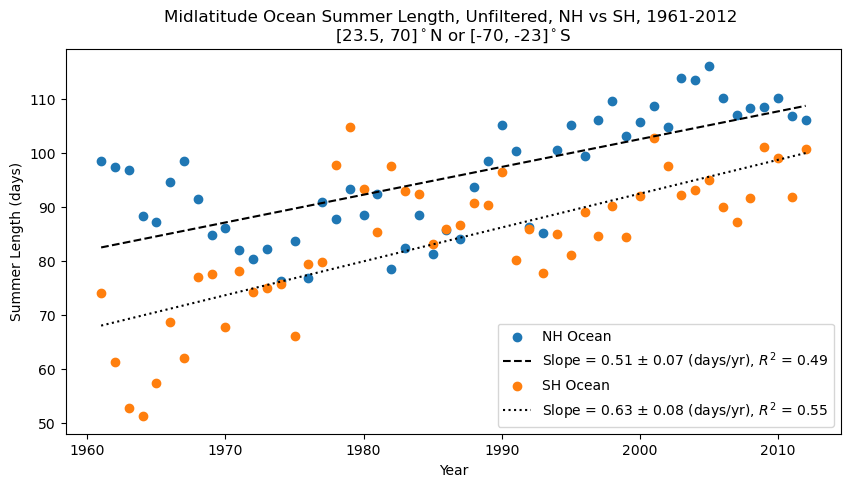

In [25]:
# take the weighted spatial mean since the latitude range of the region of interest is large

# NH
wavg_nh_ocean_sl = ds_full_ocean.SummerLength.where(((ds_full_ocean.lat >= 23.5) & (ds_full_ocean.lat <= 70))).weighted(weights).mean(dim=['lat','lon'])

# filter to 1961-2012
wavg_nh_ocean_sl = wavg_nh_ocean_sl.sel(time=slice('1961','2012'))

# x & y
x_nh = wavg_nh_ocean_sl.time.dt.year.values
y_nh = wavg_nh_ocean_sl.values

# linear fit
# error on slope via https://stackoverflow.com/questions/27634270/how-to-find-error-on-slope-and-intercept-using-numpy-polyfit
# error is stddev of 
coefs_nh, V = np.polyfit(x_nh, y_nh, 1, cov=True)
poly_nh = np.poly1d(coefs_nh)
slope_nh = np.round(coefs_nh[0],2)
slope_nh_sd = np.round(np.sqrt(V[0][0]),2)


# add in R^2 and RMSE
ymean = np.mean(y_nh)
ss_total = np.sum((y_nh - ymean)**2)
ss_res = np.sum((y_nh - poly_nh(x_nh))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_nh = np.round(1 - (ss_res / ss_total),2)

# SH
wavg_sh_ocean_sl = ds_full_ocean.SummerLength.where(((ds_full_ocean.lat <= -23.5) & (ds_full_ocean.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])

# filter to 1961-2012
wavg_sh_ocean_sl = wavg_sh_ocean_sl.sel(time=slice('1961','2012'))

# x & y
x_sh = wavg_sh_ocean_sl.time.dt.year.values
y_sh = wavg_sh_ocean_sl.values

# linear fit
coefs_sh, V = np.polyfit(x_sh, y_sh, 1, cov=True)
poly_sh = np.poly1d(coefs_sh)
slope_sh = np.round(coefs_sh[0],2)
slope_sh_sd = np.round(np.sqrt(V[0][0]),2)

# add in R^2 and RMSE
ymean = np.mean(y_sh)
ss_total = np.sum((y_sh - ymean)**2)
ss_res = np.sum((y_sh - poly_sh(x_sh))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_sh = np.round(1 - (ss_res / ss_total),2)


plt.figure(figsize=(10,5))
plt.scatter(wavg_nh_ocean_sl.time.dt.year, wavg_nh_ocean_sl, label="NH Ocean")
plt.plot(x_nh, poly_nh(x_nh), linestyle="dashed", color='k', 
         label="Slope = "+str(slope_nh)+" $\pm$ "+str(slope_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_nh))

plt.scatter(wavg_sh_ocean_sl.time.dt.year, wavg_sh_ocean_sl, label="SH Ocean")
plt.plot(x_sh, poly_sh(x_sh), linestyle="dotted", color='k',
         label="Slope = "+str(slope_sh)+" $\pm$ "+str(slope_sh_sd)+" (days/yr), $R^2$ = "+str(r_squared_sh))

plt.xlabel("Year")
plt.ylabel("Summer Length (days)")
plt.title("Midlatitude Ocean Summer Length, Unfiltered, NH vs SH, 1961-2012 \n[23.5, 70]$^\circ$N or [-70, -23]$^\circ$S")
plt.legend()
plt.show()

### Also the sensitivity test by filtering to grid cells with $R^2 \geq 0.5$

<>:60: SyntaxWarning: invalid escape sequence '\p'
<>:64: SyntaxWarning: invalid escape sequence '\p'
<>:68: SyntaxWarning: invalid escape sequence '\g'
<>:60: SyntaxWarning: invalid escape sequence '\p'
<>:64: SyntaxWarning: invalid escape sequence '\p'
<>:68: SyntaxWarning: invalid escape sequence '\g'
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/751724078.py:60: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_nh)+" $\pm$ "+str(slope_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_nh))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/751724078.py:64: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_sh)+" $\pm$ "+str(slope_sh_sd)+" (days/yr), $R^2$ = "+str(r_squared_sh))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/751724078.py:68: SyntaxWarning: invalid escape sequence '\g'
  plt.title("Midlatitude Ocean Summer Length, $R^{2} \geq 0.5$, NH vs SH, 1961-2012 \n[23.5, 70]$^\circ$N or [-7

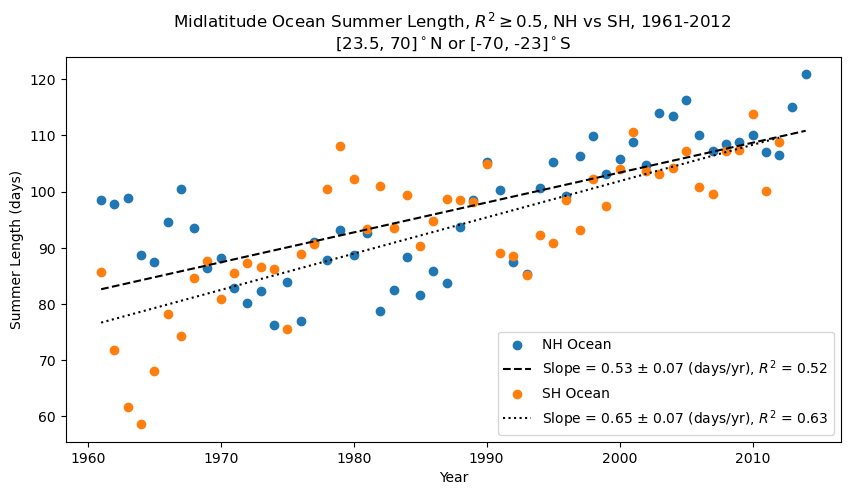

In [26]:
# filter ocean data to only cells with R^2 > 0.3
ds_full_ocean_filt = ds_full_ocean.where(ds_full_ocean.SummerR2 >= 0.5)


# take the weighted spatial mean since the latitude range of the region of interest is large

# NH
wavg_nh_ocean_sl = ds_full_ocean_filt.SummerLength.where(((ds_full_ocean_filt.lat >= 23.5) & (ds_full_ocean_filt.lat <= 70))).weighted(weights).mean(dim=['lat','lon'])

# filter to 1961-2014 - same as Lin & Wang 2022
wavg_nh_ocean_sl = wavg_nh_ocean_sl.sel(time=slice('1961','2014'))

# x & y
x_nh = wavg_nh_ocean_sl.time.dt.year.values
y_nh = wavg_nh_ocean_sl.values

# linear fit
# error on slope via https://stackoverflow.com/questions/27634270/how-to-find-error-on-slope-and-intercept-using-numpy-polyfit
# error is stddev of 
coefs_nh, V = np.polyfit(x_nh, y_nh, 1, cov=True)
poly_nh = np.poly1d(coefs_nh)
slope_nh = np.round(coefs_nh[0],2)
slope_nh_sd = np.round(np.sqrt(V[0][0]),2)


# add in R^2 and RMSE
ymean = np.mean(y_nh)
ss_total = np.sum((y_nh - ymean)**2)
ss_res = np.sum((y_nh - poly_nh(x_nh))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_nh = np.round(1 - (ss_res / ss_total),2)

# SH
wavg_sh_ocean_sl = ds_full_ocean_filt.SummerLength.where(((ds_full_ocean_filt.lat <= -23.5) & (ds_full_ocean_filt.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])

# filter to 1961-2012
wavg_sh_ocean_sl = wavg_sh_ocean_sl.sel(time=slice('1961','2012'))

# x & y
x_sh = wavg_sh_ocean_sl.time.dt.year.values
y_sh = wavg_sh_ocean_sl.values

# linear fit
coefs_sh, V = np.polyfit(x_sh, y_sh, 1, cov=True)
poly_sh = np.poly1d(coefs_sh)
slope_sh = np.round(coefs_sh[0],2)
slope_sh_sd = np.round(np.sqrt(V[0][0]),2)

# add in R^2 and RMSE
ymean = np.mean(y_sh)
ss_total = np.sum((y_sh - ymean)**2)
ss_res = np.sum((y_sh - poly_sh(x_sh))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_sh = np.round(1 - (ss_res / ss_total),2)


plt.figure(figsize=(10,5))
plt.scatter(wavg_nh_ocean_sl.time.dt.year, wavg_nh_ocean_sl, label="NH Ocean")
plt.plot(x_nh, poly_nh(x_nh), linestyle="dashed", color='k', 
         label="Slope = "+str(slope_nh)+" $\pm$ "+str(slope_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_nh))

plt.scatter(wavg_sh_ocean_sl.time.dt.year, wavg_sh_ocean_sl, label="SH Ocean")
plt.plot(x_sh, poly_sh(x_sh), linestyle="dotted", color='k',
         label="Slope = "+str(slope_sh)+" $\pm$ "+str(slope_sh_sd)+" (days/yr), $R^2$ = "+str(r_squared_sh))

plt.xlabel("Year")
plt.ylabel("Summer Length (days)")
plt.title("Midlatitude Ocean Summer Length, $R^{2} \geq 0.5$, NH vs SH, 1961-2012 \n[23.5, 70]$^\circ$N or [-70, -23]$^\circ$S")
plt.legend()
plt.show()

### how much data do we lose when we restrict to $R^2 \ge 0.5$ ?

In [27]:
#ds_land

<>:24: SyntaxWarning: invalid escape sequence '\g'
<>:24: SyntaxWarning: invalid escape sequence '\g'
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/3538309841.py:24: SyntaxWarning: invalid escape sequence '\g'
  plt.title("Mean $R^{2}$ where $R^{2} \geq 0.5$ for 1990-2023 ")


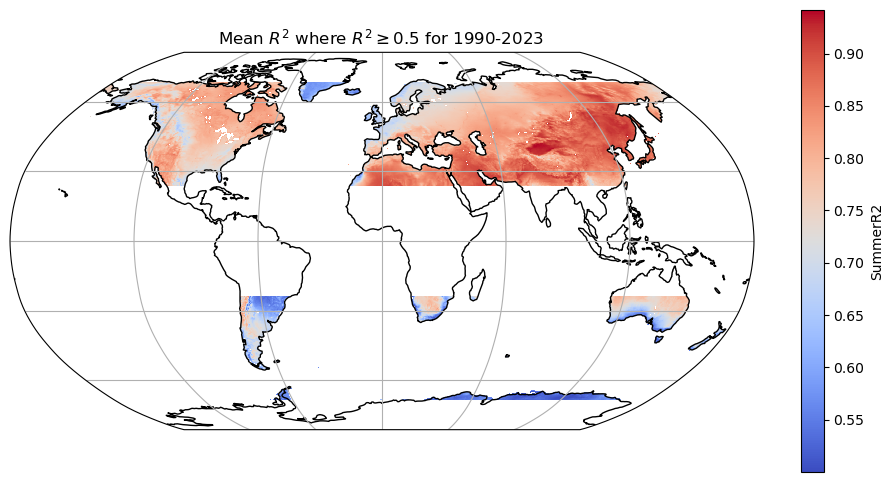

In [28]:
#avg_midlat_land_r2 = ds_land.SummerR2.where(((ds_land.lat >= 23.5) & (ds_land.lat <= 70)) | 
                                         #((ds_land.lat <= -23.5) & (ds_land.lat >= -70))).mean(dim=['time'])

# Global summer length for the year
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines()

#ds_full.SummerR2.where(ds_full.SummerR2 > 0.2).plot(
ds_land.SummerR2.where((((ds_land.lat >= 23.5) & (ds_land.lat <= 70)) | ((ds_land.lat <= -23.5) & (ds_land.lat >= -70))) & 
                       (ds_land.SummerR2 >= 0.5)).mean(dim=['time']).plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    #vmin=0,
    #vmax=365, # define range to include an entire year
    cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)

plt.title("Mean $R^{2}$ where $R^{2} \geq 0.5$ for 1990-2023 ")
#plt.savefig("./Plots/"+str(input_year)+"_SummerLength_global.png")
plt.show()

## Looks like still a good amount of data even if filtered to higher $R^2$ values <br><br>

## Time to look at trends in start/end days

## Global Midlatitudes - a bit disingenuous because of the NH/SH shift

<>:61: SyntaxWarning: invalid escape sequence '\p'
<>:65: SyntaxWarning: invalid escape sequence '\p'
<>:69: SyntaxWarning: invalid escape sequence '\c'
<>:61: SyntaxWarning: invalid escape sequence '\p'
<>:65: SyntaxWarning: invalid escape sequence '\p'
<>:69: SyntaxWarning: invalid escape sequence '\c'
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/3529409722.py:61: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" (days/yr), $R^2$ = "+str(r_squared_ocean))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/3529409722.py:65: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" (days/yr), $R^2$ = "+str(r_squared_land))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/3529409722.py:69: SyntaxWarning: invalid escape sequence '\c'
  plt.title("Global Midlatitude Summer Start Day, Unfiltered, Ocean vs Land, 1990-2023 \n[23.5

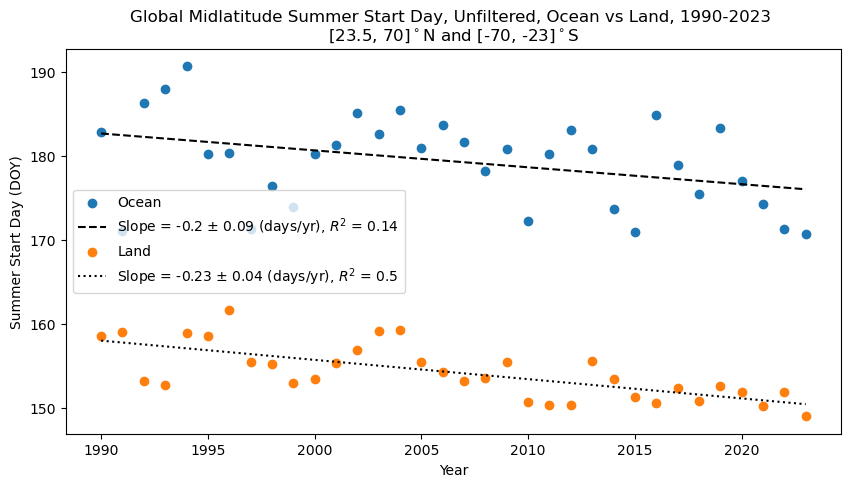

In [29]:

####
# LAND

# take the weighted spatial mean since the latitude range of the region of interest is large
wavg_midlat_land_start = ds_land.SummerStart.where(((ds_land.lat >= 23.5) & (ds_land.lat <= 70)) | 
                                         ((ds_land.lat <= -23.5) & (ds_land.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])

# x & y
x_land = wavg_midlat_land_start.time.dt.year.values
y_land = wavg_midlat_land_start.values

# linear fit
# error on slope via https://stackoverflow.com/questions/27634270/how-to-find-error-on-slope-and-intercept-using-numpy-polyfit
# error is stddev of 
coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
poly_land = np.poly1d(coefs_land)
slope_land = np.round(coefs_land[0],2)
slope_land_sd = np.round(np.sqrt(V[0][0]),2)


# add in R^2 and RMSE
ymean = np.mean(y_land)
ss_total = np.sum((y_land - ymean)**2)
ss_res = np.sum((y_land - poly_land(x_land))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_land = np.round(1 - (ss_res / ss_total),2)


####
# OCEAN

wavg_midlat_ocean_start = ds_ocean.SummerStart.where(((ds_ocean.lat >= 23.5) & (ds_ocean.lat <= 70)) |
                                           ((ds_ocean.lat <= -23.5) & (ds_ocean.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])

# x & y
x_ocean = wavg_midlat_ocean_start.time.dt.year.values
y_ocean = wavg_midlat_ocean_start.values

# linear fit
# error on slope via https://stackoverflow.com/questions/27634270/how-to-find-error-on-slope-and-intercept-using-numpy-polyfit
# error is stddev of 
coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
poly_ocean = np.poly1d(coefs_ocean)
slope_ocean = np.round(coefs_ocean[0],2)
slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)


# add in R^2 and RMSE
ymean = np.mean(y_ocean)
ss_total = np.sum((y_ocean - ymean)**2)
ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_ocean = np.round(1 - (ss_res / ss_total),2)



# plot it
plt.figure(figsize=(10,5))
plt.scatter(wavg_midlat_ocean_start.time.dt.year, wavg_midlat_ocean_start, label="Ocean")
plt.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", color='k', 
         label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" (days/yr), $R^2$ = "+str(r_squared_ocean))

plt.scatter(wavg_midlat_land_start.time.dt.year, wavg_midlat_land_start, label="Land")
plt.plot(x_land, poly_land(x_land), linestyle="dotted", color='k',
         label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" (days/yr), $R^2$ = "+str(r_squared_land))

plt.xlabel("Year")
plt.ylabel("Summer Start Day (DOY)")
plt.title("Global Midlatitude Summer Start Day, Unfiltered, Ocean vs Land, 1990-2023 \n[23.5, 70]$^\circ$N and [-70, -23]$^\circ$S")
plt.legend()
plt.show()


<>:61: SyntaxWarning: invalid escape sequence '\p'
<>:65: SyntaxWarning: invalid escape sequence '\p'
<>:69: SyntaxWarning: invalid escape sequence '\c'
<>:61: SyntaxWarning: invalid escape sequence '\p'
<>:65: SyntaxWarning: invalid escape sequence '\p'
<>:69: SyntaxWarning: invalid escape sequence '\c'
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/3139128392.py:61: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" (days/yr), $R^2$ = "+str(r_squared_ocean))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/3139128392.py:65: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" (days/yr), $R^2$ = "+str(r_squared_land))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/3139128392.py:69: SyntaxWarning: invalid escape sequence '\c'
  plt.title("Global Midlatitude Summer End Day, Unfiltered, Ocean vs Land, 1990-2023 \n[23.5, 

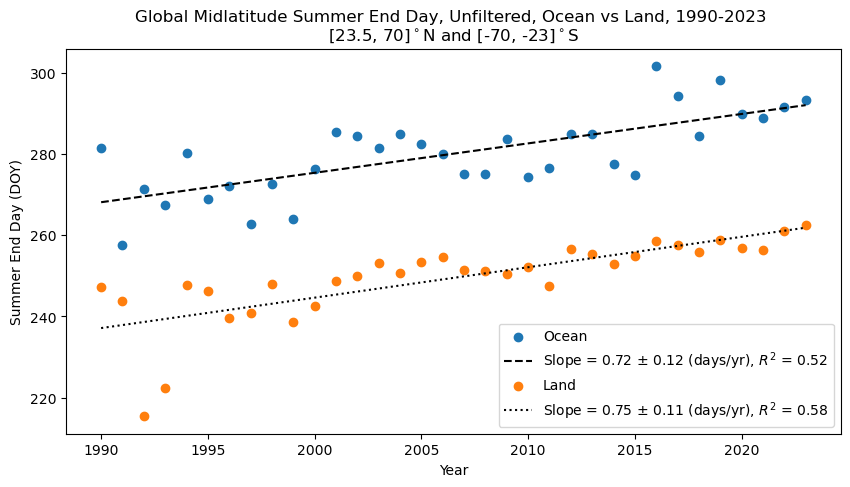

In [30]:
####
# LAND

# take the weighted spatial mean since the latitude range of the region of interest is large
wavg_midlat_land_end = ds_land.SummerEnd.where(((ds_land.lat >= 23.5) & (ds_land.lat <= 70)) | 
                                         ((ds_land.lat <= -23.5) & (ds_land.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])

# x & y
x_land = wavg_midlat_land_end.time.dt.year.values
y_land = wavg_midlat_land_end.values

# linear fit
# error on slope via https://stackoverflow.com/questions/27634270/how-to-find-error-on-slope-and-intercept-using-numpy-polyfit
# error is stddev of 
coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
poly_land = np.poly1d(coefs_land)
slope_land = np.round(coefs_land[0],2)
slope_land_sd = np.round(np.sqrt(V[0][0]),2)


# add in R^2 and RMSE
ymean = np.mean(y_land)
ss_total = np.sum((y_land - ymean)**2)
ss_res = np.sum((y_land - poly_land(x_land))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_land = np.round(1 - (ss_res / ss_total),2)


####
# OCEAN

wavg_midlat_ocean_end = ds_ocean.SummerEnd.where(((ds_ocean.lat >= 23.5) & (ds_ocean.lat <= 70)) |
                                           ((ds_ocean.lat <= -23.5) & (ds_ocean.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])

# x & y
x_ocean = wavg_midlat_ocean_end.time.dt.year.values
y_ocean = wavg_midlat_ocean_end.values

# linear fit
# error on slope via https://stackoverflow.com/questions/27634270/how-to-find-error-on-slope-and-intercept-using-numpy-polyfit
# error is stddev of 
coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
poly_ocean = np.poly1d(coefs_ocean)
slope_ocean = np.round(coefs_ocean[0],2)
slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)


# add in R^2 and RMSE
ymean = np.mean(y_ocean)
ss_total = np.sum((y_ocean - ymean)**2)
ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_ocean = np.round(1 - (ss_res / ss_total),2)



# plot it
plt.figure(figsize=(10,5))
plt.scatter(wavg_midlat_ocean_end.time.dt.year, wavg_midlat_ocean_end, label="Ocean")
plt.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", color='k', 
         label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" (days/yr), $R^2$ = "+str(r_squared_ocean))

plt.scatter(wavg_midlat_land_end.time.dt.year, wavg_midlat_land_end, label="Land")
plt.plot(x_land, poly_land(x_land), linestyle="dotted", color='k',
         label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" (days/yr), $R^2$ = "+str(r_squared_land))

plt.xlabel("Year")
plt.ylabel("Summer End Day (DOY)")
plt.title("Global Midlatitude Summer End Day, Unfiltered, Ocean vs Land, 1990-2023 \n[23.5, 70]$^\circ$N and [-70, -23]$^\circ$S")
plt.legend()
plt.show()


## <br>Now NH alone and SH alone, a more correct comparison <br>

<>:59: SyntaxWarning: invalid escape sequence '\p'
<>:63: SyntaxWarning: invalid escape sequence '\p'
<>:67: SyntaxWarning: invalid escape sequence '\c'
<>:59: SyntaxWarning: invalid escape sequence '\p'
<>:63: SyntaxWarning: invalid escape sequence '\p'
<>:67: SyntaxWarning: invalid escape sequence '\c'
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/1592440553.py:59: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" (days/yr), $R^2$ = "+str(r_squared_ocean))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/1592440553.py:63: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" (days/yr), $R^2$ = "+str(r_squared_land))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/1592440553.py:67: SyntaxWarning: invalid escape sequence '\c'
  plt.title("NH Midlatitude Summer Start Day, Unfiltered, Ocean vs Land, 1990-2023 \n[23.5, 70

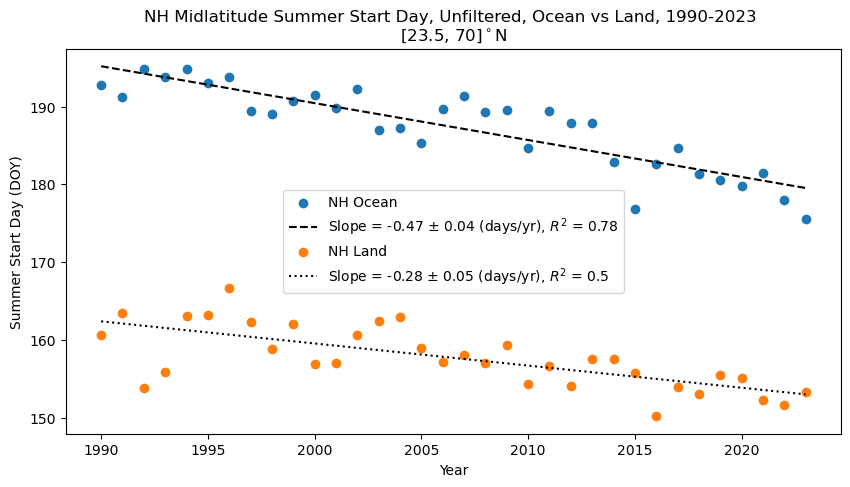

In [31]:

####
# LAND

# take the weighted spatial mean since the latitude range of the region of interest is large
wavg_nh_midlat_land_start = ds_land.SummerStart.where(((ds_land.lat >= 23.5) & (ds_land.lat <= 70))).weighted(weights).mean(dim=['lat','lon'])

# x & y
x_land = wavg_nh_midlat_land_start.time.dt.year.values
y_land = wavg_nh_midlat_land_start.values

# linear fit
# error on slope via https://stackoverflow.com/questions/27634270/how-to-find-error-on-slope-and-intercept-using-numpy-polyfit
# error is stddev of 
coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
poly_land = np.poly1d(coefs_land)
slope_land = np.round(coefs_land[0],2)
slope_land_sd = np.round(np.sqrt(V[0][0]),2)


# add in R^2 and RMSE
ymean = np.mean(y_land)
ss_total = np.sum((y_land - ymean)**2)
ss_res = np.sum((y_land - poly_land(x_land))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_land = np.round(1 - (ss_res / ss_total),2)


####
# OCEAN

wavg_nh_midlat_ocean_start = ds_ocean.SummerStart.where(((ds_ocean.lat >= 23.5) & (ds_ocean.lat <= 70))).weighted(weights).mean(dim=['lat','lon'])

# x & y
x_ocean = wavg_nh_midlat_ocean_start.time.dt.year.values
y_ocean = wavg_nh_midlat_ocean_start.values

# linear fit
# error on slope via https://stackoverflow.com/questions/27634270/how-to-find-error-on-slope-and-intercept-using-numpy-polyfit
# error is stddev of 
coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
poly_ocean = np.poly1d(coefs_ocean)
slope_ocean = np.round(coefs_ocean[0],2)
slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)


# add in R^2 and RMSE
ymean = np.mean(y_ocean)
ss_total = np.sum((y_ocean - ymean)**2)
ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_ocean = np.round(1 - (ss_res / ss_total),2)



# plot it
plt.figure(figsize=(10,5))
plt.scatter(wavg_nh_midlat_ocean_start.time.dt.year, wavg_nh_midlat_ocean_start, label="NH Ocean")
plt.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", color='k', 
         label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" (days/yr), $R^2$ = "+str(r_squared_ocean))

plt.scatter(wavg_nh_midlat_land_start.time.dt.year, wavg_nh_midlat_land_start, label="NH Land")
plt.plot(x_land, poly_land(x_land), linestyle="dotted", color='k',
         label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" (days/yr), $R^2$ = "+str(r_squared_land))

plt.xlabel("Year")
plt.ylabel("Summer Start Day (DOY)")
plt.title("NH Midlatitude Summer Start Day, Unfiltered, Ocean vs Land, 1990-2023 \n[23.5, 70]$^\circ$N")# and [-70, -23]$^\circ$S")
plt.legend()
plt.show()


<>:59: SyntaxWarning: invalid escape sequence '\p'
<>:63: SyntaxWarning: invalid escape sequence '\p'
<>:67: SyntaxWarning: invalid escape sequence '\c'
<>:59: SyntaxWarning: invalid escape sequence '\p'
<>:63: SyntaxWarning: invalid escape sequence '\p'
<>:67: SyntaxWarning: invalid escape sequence '\c'
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/2071400315.py:59: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" (days/yr), $R^2$ = "+str(r_squared_ocean))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/2071400315.py:63: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" (days/yr), $R^2$ = "+str(r_squared_land))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/2071400315.py:67: SyntaxWarning: invalid escape sequence '\c'
  plt.title("NH Midlatitude Summer End Day, Unfiltered, Ocean vs Land, 1990-2023 \n[23.5, 70]$

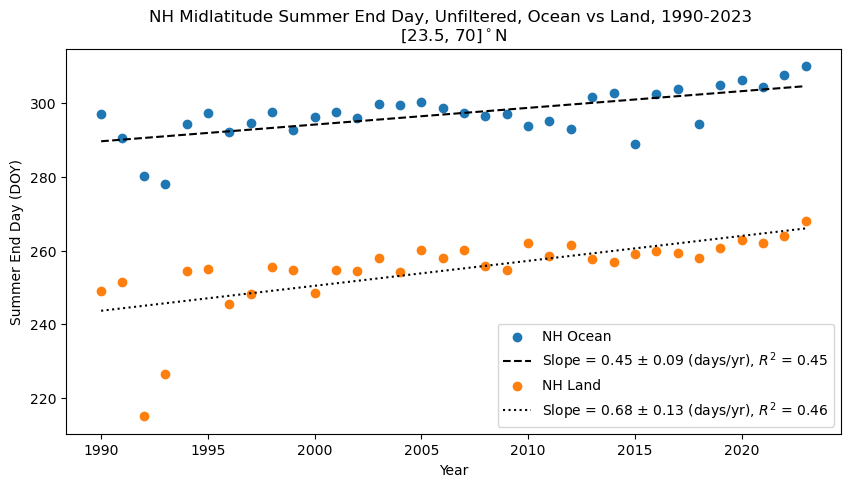

In [32]:

####
# LAND

# take the weighted spatial mean since the latitude range of the region of interest is large
wavg_nh_midlat_land_end = ds_land.SummerEnd.where(((ds_land.lat >= 23.5) & (ds_land.lat <= 70))).weighted(weights).mean(dim=['lat','lon'])

# x & y
x_land = wavg_nh_midlat_land_end.time.dt.year.values
y_land = wavg_nh_midlat_land_end.values

# linear fit
# error on slope via https://stackoverflow.com/questions/27634270/how-to-find-error-on-slope-and-intercept-using-numpy-polyfit
# error is stddev of 
coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
poly_land = np.poly1d(coefs_land)
slope_land = np.round(coefs_land[0],2)
slope_land_sd = np.round(np.sqrt(V[0][0]),2)


# add in R^2 and RMSE
ymean = np.mean(y_land)
ss_total = np.sum((y_land - ymean)**2)
ss_res = np.sum((y_land - poly_land(x_land))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_land = np.round(1 - (ss_res / ss_total),2)


####
# OCEAN

wavg_nh_midlat_ocean_end = ds_ocean.SummerEnd.where(((ds_ocean.lat >= 23.5) & (ds_ocean.lat <= 70))).weighted(weights).mean(dim=['lat','lon'])

# x & y
x_ocean = wavg_nh_midlat_ocean_end.time.dt.year.values
y_ocean = wavg_nh_midlat_ocean_end.values

# linear fit
# error on slope via https://stackoverflow.com/questions/27634270/how-to-find-error-on-slope-and-intercept-using-numpy-polyfit
# error is stddev of 
coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
poly_ocean = np.poly1d(coefs_ocean)
slope_ocean = np.round(coefs_ocean[0],2)
slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)


# add in R^2 and RMSE
ymean = np.mean(y_ocean)
ss_total = np.sum((y_ocean - ymean)**2)
ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_ocean = np.round(1 - (ss_res / ss_total),2)



# plot it
plt.figure(figsize=(10,5))
plt.scatter(wavg_nh_midlat_ocean_end.time.dt.year, wavg_nh_midlat_ocean_end, label="NH Ocean")
plt.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", color='k', 
         label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" (days/yr), $R^2$ = "+str(r_squared_ocean))

plt.scatter(wavg_nh_midlat_land_end.time.dt.year, wavg_nh_midlat_land_end, label="NH Land")
plt.plot(x_land, poly_land(x_land), linestyle="dotted", color='k',
         label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" (days/yr), $R^2$ = "+str(r_squared_land))

plt.xlabel("Year")
plt.ylabel("Summer End Day (DOY)")
plt.title("NH Midlatitude Summer End Day, Unfiltered, Ocean vs Land, 1990-2023 \n[23.5, 70]$^\circ$N")# and [-70, -23]$^\circ$S")
plt.legend()
plt.show()


## <br>It appears that for NH land the **END** is moving out almost twice as fast as the start is moving earlier, while for the ocean the start and end are moving with ~equal rates. Wang et al 2021 says the start is moving out faster, Lin & Wang 2022 say symmetry in start/end, and Park 2018 says start is moving out faster (for NH) <br><br> Also, how does this connect with McKinnon et al 2016 who found that in the NH the entire T distribution was shifting. Is this compatible?

## Check SH

<>:59: SyntaxWarning: invalid escape sequence '\p'
<>:63: SyntaxWarning: invalid escape sequence '\p'
<>:67: SyntaxWarning: invalid escape sequence '\c'
<>:59: SyntaxWarning: invalid escape sequence '\p'
<>:63: SyntaxWarning: invalid escape sequence '\p'
<>:67: SyntaxWarning: invalid escape sequence '\c'
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/4280606957.py:59: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" (days/yr), $R^2$ = "+str(r_squared_ocean))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/4280606957.py:63: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" (days/yr), $R^2$ = "+str(r_squared_land))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/4280606957.py:67: SyntaxWarning: invalid escape sequence '\c'
  plt.title("SH Midlatitude Summer Start Day, Unfiltered, Ocean vs Land, 1990-2023 \n[-70, -23

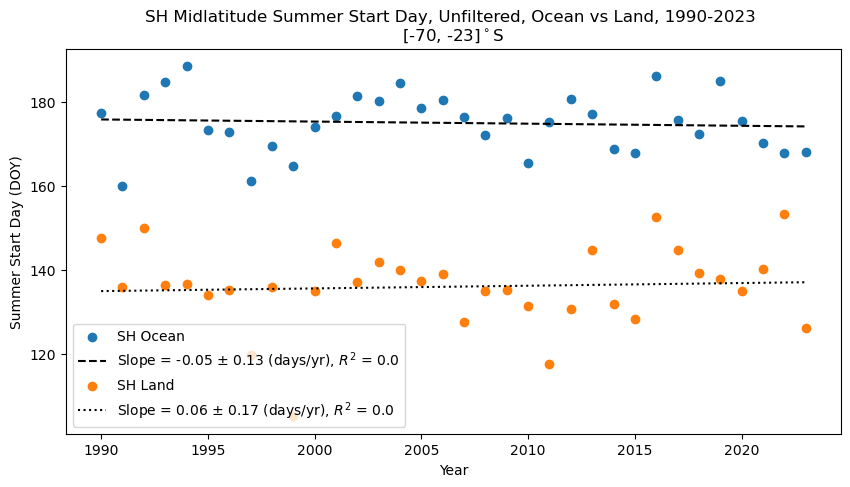

In [33]:

####
# LAND

# take the weighted spatial mean since the latitude range of the region of interest is large
wavg_sh_midlat_land_start = ds_land.SummerStart.where(((ds_land.lat <= -23.5) & (ds_land.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])

# x & y
x_land = wavg_sh_midlat_land_start.time.dt.year.values
y_land = wavg_sh_midlat_land_start.values

# linear fit
# error on slope via https://stackoverflow.com/questions/27634270/how-to-find-error-on-slope-and-intercept-using-numpy-polyfit
# error is stddev of 
coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
poly_land = np.poly1d(coefs_land)
slope_land = np.round(coefs_land[0],2)
slope_land_sd = np.round(np.sqrt(V[0][0]),2)


# add in R^2 and RMSE
ymean = np.mean(y_land)
ss_total = np.sum((y_land - ymean)**2)
ss_res = np.sum((y_land - poly_land(x_land))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_land = np.round(1 - (ss_res / ss_total),2)


####
# OCEAN

wavg_sh_midlat_ocean_start = ds_ocean.SummerStart.where(((ds_ocean.lat <= -23.5) & (ds_ocean.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])

# x & y
x_ocean = wavg_sh_midlat_ocean_start.time.dt.year.values
y_ocean = wavg_sh_midlat_ocean_start.values

# linear fit
# error on slope via https://stackoverflow.com/questions/27634270/how-to-find-error-on-slope-and-intercept-using-numpy-polyfit
# error is stddev of 
coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
poly_ocean = np.poly1d(coefs_ocean)
slope_ocean = np.round(coefs_ocean[0],2)
slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)


# add in R^2 and RMSE
ymean = np.mean(y_ocean)
ss_total = np.sum((y_ocean - ymean)**2)
ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_ocean = np.round(1 - (ss_res / ss_total),2)



# plot it
plt.figure(figsize=(10,5))
plt.scatter(wavg_sh_midlat_ocean_start.time.dt.year, wavg_sh_midlat_ocean_start, label="SH Ocean")
plt.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", color='k', 
         label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" (days/yr), $R^2$ = "+str(r_squared_ocean))

plt.scatter(wavg_sh_midlat_land_start.time.dt.year, wavg_sh_midlat_land_start, label="SH Land")
plt.plot(x_land, poly_land(x_land), linestyle="dotted", color='k',
         label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" (days/yr), $R^2$ = "+str(r_squared_land))

plt.xlabel("Year")
plt.ylabel("Summer Start Day (DOY)")
plt.title("SH Midlatitude Summer Start Day, Unfiltered, Ocean vs Land, 1990-2023 \n[-70, -23]$^\circ$S")
plt.legend()
plt.show()


<>:59: SyntaxWarning: invalid escape sequence '\p'
<>:63: SyntaxWarning: invalid escape sequence '\p'
<>:67: SyntaxWarning: invalid escape sequence '\c'
<>:59: SyntaxWarning: invalid escape sequence '\p'
<>:63: SyntaxWarning: invalid escape sequence '\p'
<>:67: SyntaxWarning: invalid escape sequence '\c'
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/2342814266.py:59: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" (days/yr), $R^2$ = "+str(r_squared_ocean))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/2342814266.py:63: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" (days/yr), $R^2$ = "+str(r_squared_land))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_92142/2342814266.py:67: SyntaxWarning: invalid escape sequence '\c'
  plt.title("SH Midlatitude Summer End Day, Unfiltered, Ocean vs Land, 1990-2023 \n[-70, -23]$

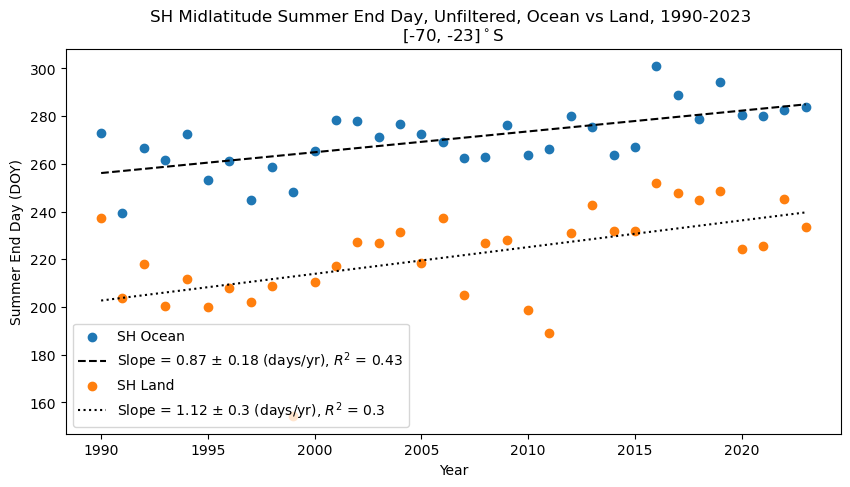

In [34]:

####
# LAND

# take the weighted spatial mean since the latitude range of the region of interest is large
wavg_sh_midlat_land_end = ds_land.SummerEnd.where(((ds_land.lat <= -23.5) & (ds_land.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])

# x & y
x_land = wavg_sh_midlat_land_end.time.dt.year.values
y_land = wavg_sh_midlat_land_end.values

# linear fit
# error on slope via https://stackoverflow.com/questions/27634270/how-to-find-error-on-slope-and-intercept-using-numpy-polyfit
# error is stddev of 
coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
poly_land = np.poly1d(coefs_land)
slope_land = np.round(coefs_land[0],2)
slope_land_sd = np.round(np.sqrt(V[0][0]),2)


# add in R^2 and RMSE
ymean = np.mean(y_land)
ss_total = np.sum((y_land - ymean)**2)
ss_res = np.sum((y_land - poly_land(x_land))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_land = np.round(1 - (ss_res / ss_total),2)


####
# OCEAN

wavg_sh_midlat_ocean_end = ds_ocean.SummerEnd.where(((ds_ocean.lat <= -23.5) & (ds_ocean.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])

# x & y
x_ocean = wavg_sh_midlat_ocean_end.time.dt.year.values
y_ocean = wavg_sh_midlat_ocean_end.values

# linear fit
# error on slope via https://stackoverflow.com/questions/27634270/how-to-find-error-on-slope-and-intercept-using-numpy-polyfit
# error is stddev of 
coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
poly_ocean = np.poly1d(coefs_ocean)
slope_ocean = np.round(coefs_ocean[0],2)
slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)


# add in R^2 and RMSE
ymean = np.mean(y_ocean)
ss_total = np.sum((y_ocean - ymean)**2)
ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_ocean = np.round(1 - (ss_res / ss_total),2)



# plot it
plt.figure(figsize=(10,5))
plt.scatter(wavg_sh_midlat_ocean_end.time.dt.year, wavg_sh_midlat_ocean_end, label="SH Ocean")
plt.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", color='k', 
         label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" (days/yr), $R^2$ = "+str(r_squared_ocean))

plt.scatter(wavg_sh_midlat_land_end.time.dt.year, wavg_sh_midlat_land_end, label="SH Land")
plt.plot(x_land, poly_land(x_land), linestyle="dotted", color='k',
         label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" (days/yr), $R^2$ = "+str(r_squared_land))

plt.xlabel("Year")
plt.ylabel("Summer End Day (DOY)")
plt.title("SH Midlatitude Summer End Day, Unfiltered, Ocean vs Land, 1990-2023 \n[-70, -23]$^\circ$S")
plt.legend()
plt.show()


## For the SH, it appears the start day is stationary while the end is moving later quite rapidly for both land and ocean! This contrasts with Weller et al 2020 who say that start is moving out slightly which contributes more to the increased length AND they claim that using a 3rd degree polynomial amplifies this effect. We're seeing the opposite finding. <br>

## <br><br> Weller et al says that asymmetry in summer lengthening was sensitive to smoothing method so try the above filtered to better $R^2$ to see if it stays this flat or not??



In [35]:
# filter land data to only cells with R^2 > 0.5
#ds_full_land_filt = ds_full_land.where(ds_full_land.SummerR2 >= 0.5)